# Intermitência renovável, despacho hidrotérmico e MFG locacional (v3)

Backend empírico/computacional do paper *Mean Field Games in Renewable Energy
Markets*. Esta versão corrige os pontos do review do v2:

- Modelo situacional: distingue `Rev_i_model` (receita total) de `R_cap_i_model`
  (receita capturada por MWh); curtailment solar explícito; nuclear separada da
  térmica despachável; diagnóstico de factibilidade.
- Despacho com **estado de reservatório** `S_t` e valor da água renomeado para
  `water_opportunity_cost` / `shadow_water_value_proxy`.
- Fatores de captura por subsistema × fonte × estação × tipo_dia × métrica de preço.
- Mapas estáticos: geração renovável, preços/curtailment, alocação privada × social.
- **Mean Field Game locacional discreto formal**: estado individual, ação,
  distribuição populacional `m`, política, atualização forward, clearing,
  iteração de ponto fixo.
- Livre entrada vs orçamento fixo com interpretação correta.
- Inventário CSV + validação assertiva.

## Glossário de notação

### Carga × demanda
- `L_RB`, `G_MMGD`, `L_global`, `L_net_s`, `L_res`, `dL_res` — variáveis de carga.
- `D` — reservado para demanda econômica abstrata; não usado.

### Preços
- `CMO_obs` — Custo Marginal de Operação observado.
- `PLD_obs` — PLD oficial (NaN, indisponível na base).
- `PLD_hat` — proxy de PLD via clip do CMO em tetos regulatórios.
- `lambda_model` — preço-sombra dos modelos de otimização. **Nunca** chamado de CMO/PLD.

### Geração
- `G_s_total`, `G_w_total`, `G_h_total` — solar centralizada, eólica, hidro observadas.
- `G_th_total` — térmica **despachável** observada.
- `G_nuc_inflex` — nuclear/inflexível observada.
- `G_n_total` — **DEPRECATED**: térmica + nuclear; evitar — usar `G_th_total` para custo marginal.

### Capacidades (proxy)
- `K_s_eff_p99`, `K_w_eff_p99`, `K_h_eff_p99`, `K_th_eff_p99`, `K_nuc_eff_p99` — capacidades
  efetivas via p99 da geração horária. Não são `K_*_inst` oficiais.

### Hidrologia
- `S_t` — estado de reservatório (proxy de energia armazenada, MWh-equivalentes).
- `water_opportunity_cost` — penalidade `θ_w · ∑h_t` no objetivo (R$/MWh).
- `shadow_water_value_proxy` — valor de continuação `−V_S · S_T` (não é valor terminal
  rigoroso, pois o horizonte é típico/recorrente).

### MFG locacional
- Estado individual: `x = (ell, k_bin, theta_bin)`.
- Distribuição `m[ell, k_bin, theta_bin]` com `m.sum() == 1`.
- Ações: `a ∈ {-Δk, 0, +Δk}` (capacidade) + opcional `relocate_to_<ell>`.
- `policy[x]` — ação ótima por estado dado `lambda_loc`.
- `lambda_loc[ell, t]` — preço-sombra do clearing locacional.


## 0. Setup, imports e diretórios de saída

In [1]:
from __future__ import annotations
import os, sys, math, json, warnings, time
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import matplotlib.cm as cm
import seaborn as sns
import cvxpy as cp

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140,
    "axes.titleweight": "bold",
    "axes.spines.right": False, "axes.spines.top": False,
    "font.size": 10,
})


def _find_project_root(start: Path | None = None, marker: str = "validate_model") -> Path:
    cur = Path(start or Path.cwd()).resolve()
    for cand in [cur, *cur.parents]:
        if (cand / marker).exists():
            return cand
    return cur


ROOT       = _find_project_root()
DATA       = ROOT / "validate_model" / "data"
GEO_DIR    = ROOT / "data" / "geospatial"
OUT        = ROOT / "outputs"
FIG_DIR    = OUT / "figures"
TABLE_DIR  = OUT / "tables"
CACHE_DIR  = OUT / "cache"
for d in (OUT, FIG_DIR, TABLE_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from validate_model.pipeline import (
    SINPaths, build_panel, load_cmo_horario, load_hidrologia,
    canonical_subsys,
)

print(f"ROOT   : {ROOT}")
print(f"OUT    : {OUT}")
print(f"cvxpy  : {cp.__version__}")
print(f"pandas : {pd.__version__}")

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)


ROOT   : C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy
OUT    : C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy\outputs
cvxpy  : 1.8.2
pandas : 2.2.3


## 1. Painel SIN, CMO horário e hidrologia (cache)

In [2]:
DATE_MIN = pd.Timestamp("2025-01-01 00:00:00")
DATE_MAX = pd.Timestamp("2025-10-31 23:00:00")

SUBSYS_ORDER = ["N", "NE", "SE", "S"]
SUB_LABEL = {"N": "Norte", "NE": "Nordeste", "SE": "Sudeste/CO", "S": "Sul"}
SUB_COLOR = {"N": "#1f77b4", "NE": "#d62728", "SE": "#2ca02c", "S": "#9467bd"}

PANEL_CACHE = CACHE_DIR / "panel_hourly_v3.parquet"
CMO_CACHE   = CACHE_DIR / "cmo_hourly_v3.parquet"
HYDRO_CACHE = CACHE_DIR / "hidrologia_v3.parquet"

paths = SINPaths(root=str(ROOT / "validate_model"), year=2025)

if PANEL_CACHE.exists():
    panel = pd.read_parquet(PANEL_CACHE)
else:
    panel = build_panel(paths)
    panel.to_parquet(PANEL_CACHE, index=False)
if CMO_CACHE.exists():
    cmo = pd.read_parquet(CMO_CACHE)
else:
    cmo = load_cmo_horario(paths.cmo_semihorario_path)
    cmo.to_parquet(CMO_CACHE, index=False)
if HYDRO_CACHE.exists():
    hydro = pd.read_parquet(HYDRO_CACHE)
else:
    hydro = load_hidrologia(paths.hidro_di_path)
    hydro.to_parquet(HYDRO_CACHE, index=False)

panel = panel[(panel["din_instante"] >= DATE_MIN) & (panel["din_instante"] <= DATE_MAX)].copy()
cmo   = cmo[(cmo["din_instante"] >= DATE_MIN) & (cmo["din_instante"] <= DATE_MAX)].copy()
hydro = hydro[(hydro["din_instante"] >= DATE_MIN) & (hydro["din_instante"] <= DATE_MAX)].copy()

print(f"Painel : {len(panel):>10,}")
print(f"CMO    : {len(cmo):>10,}")
print(f"Hidro  : {len(hydro):>10,}")


Painel :     29,184
CMO    :     29,088
Hidro  :        304


## 2. Calendário

In [3]:
SOUTH_HEMI_SEASON = {
    12: "verao", 1: "verao", 2: "verao",
    3: "outono", 4: "outono", 5: "outono",
    6: "inverno", 7: "inverno", 8: "inverno",
    9: "primavera", 10: "primavera", 11: "primavera",
}
SEASON_ORDER = ["verao", "outono", "inverno", "primavera"]
FERIADOS_2025 = {
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18",
    "2025-04-21", "2025-05-01", "2025-06-19", "2025-09-07",
    "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20",
    "2025-12-25",
}


def add_calendar(df: pd.DataFrame, dt_col: str = "din_instante") -> pd.DataFrame:
    df = df.copy()
    t = df[dt_col]
    df["data"]       = t.dt.date
    df["ano"]        = t.dt.year
    df["mes"]        = t.dt.month
    df["dia_semana"] = t.dt.dayofweek
    df["hora"]       = t.dt.hour
    df["estacao"]    = df["mes"].map(SOUTH_HEMI_SEASON)
    feriados = pd.to_datetime(list(FERIADOS_2025)).date
    is_feriado = df["data"].isin(feriados)
    df["tipo_dia"] = np.select(
        [is_feriado, df["dia_semana"] == 5, df["dia_semana"] == 6],
        ["feriado", "sabado", "domingo"],
        default="util",
    )
    df["tipo_dia_g"] = np.where(df["tipo_dia"] == "util", "util", "fim_semana_feriado")
    return df


panel = add_calendar(panel)
cmo   = add_calendar(cmo)
print(panel.groupby("estacao", observed=False).size().reindex(SEASON_ORDER))


estacao
verao        5664
outono       8832
inverno      8832
primavera    5856
dtype: int64


## 3. Variáveis de **carga** `L_*` e separação MMGD/centralizada

Renomeia `D` → `L_RB`. Define `L_global`, `L_net_s`, `L_res`, `dL_res`.
Os campos `D_global`, `D_net`, `D_res` permanecem apenas como aliases deprecated.


In [4]:
print("Re-lendo solar para isolar MMGD vs centralizada...")
sol_raw = pd.read_csv(paths.solar_path, sep=";", parse_dates=["din_instante"])
sol_raw["din_instante"] = sol_raw["din_instante"].dt.floor("h")
sol_raw["id_subsistema"] = sol_raw["nom_subsistema"].astype(str).map(canonical_subsys)
sol_raw = sol_raw[(sol_raw["din_instante"] >= DATE_MIN) & (sol_raw["din_instante"] <= DATE_MAX)]
is_mmgd = sol_raw["cod_modalidadeoperacao"].astype(str).str.contains("MMGD", case=False, regex=False)

sol_mmgd = (sol_raw[is_mmgd]
    .groupby(["din_instante", "id_subsistema"], as_index=False)["val_geracao"].sum()
    .rename(columns={"val_geracao": "G_MMGD"}))
sol_cen = (sol_raw[~is_mmgd]
    .groupby(["din_instante", "id_subsistema"], as_index=False)["val_geracao"].sum()
    .rename(columns={"val_geracao": "G_s_total"}))

panel = (panel
    .merge(sol_mmgd, on=["din_instante", "id_subsistema"], how="left")
    .merge(sol_cen,  on=["din_instante", "id_subsistema"], how="left"))
panel["G_MMGD"]      = panel["G_MMGD"].fillna(0.0)
panel["G_s_total"]   = panel["G_s_total"].fillna(0.0)
panel["G_w_total"]   = panel["gr"].fillna(0.0)
panel["G_h_total"]   = panel["gh"].fillna(0.0)
panel["G_th_total"]  = panel["g_th_obs"].fillna(0.0)         # térmica DESPACHÁVEL
panel["G_nuc_inflex"]= panel["g_nuc_obs"].fillna(0.0)        # nuclear INFLEXÍVEL
panel["G_n_total"]   = panel["G_th_total"] + panel["G_nuc_inflex"]   # DEPRECATED — usar G_th_total para custo marginal

panel = panel.rename(columns={"D": "L_RB"})
panel["L_RB"]     = pd.to_numeric(panel["L_RB"], errors="coerce")
panel["L_global"] = panel["L_RB"] + panel["G_MMGD"]
panel["L_net_s"]  = panel["L_global"] - panel["G_s_total"]
panel["L_res"]    = panel["L_global"] - panel["G_s_total"] - panel["G_w_total"]
panel["D_global"] = panel["L_global"]
panel["D_net"]    = panel["L_net_s"]
panel["D_res"]    = panel["L_res"]

panel = panel.sort_values(["id_subsistema", "din_instante"]).reset_index(drop=True)
panel["dL_res"]   = panel.groupby("id_subsistema")["L_res"].diff()

print(panel.groupby("id_subsistema")
      [["L_RB", "L_global", "L_res", "G_s_total", "G_w_total",
        "G_th_total", "G_nuc_inflex"]].mean().round(0).to_string())


Re-lendo solar para isolar MMGD vs centralizada...


                  L_RB  L_global    L_res  G_s_total  G_w_total  G_th_total  G_nuc_inflex
id_subsistema                                                                            
N               8213.0    8789.0   8595.0        1.0      196.0      2072.0           0.0
NE             13177.0   14464.0    105.0     1937.0    12491.0       636.0           0.0
S              13769.0   14978.0  14276.0        1.0      703.0      1060.0           0.0
SE             44111.0   47490.0  45803.0     1682.0        6.0      4366.0        1766.0


## 4. Auditoria de cobertura dos dados

In [5]:
def audit_dataset(name: str, df: pd.DataFrame, dt_col: str = "din_instante") -> dict | None:
    if dt_col not in df.columns:
        return None
    t = pd.to_datetime(df[dt_col], errors="coerce").dropna()
    if len(t) == 0:
        return {"dataset": name, "min_datetime": None, "max_datetime": None,
                "n_obs": 0, "missing_rate": np.nan}
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    miss = float(df[num].isna().mean().mean()) if num else np.nan
    return {"dataset": name, "min_datetime": str(t.min()),
            "max_datetime": str(t.max()), "n_obs": int(len(df)),
            "missing_rate": miss}


records = []
for name, df in [("panel_SIN", panel), ("cmo_horario", cmo),
                 ("hidrologia_diaria", hydro), ("solar_raw", sol_raw)]:
    rec = audit_dataset(name, df)
    if rec:
        records.append(rec)
tab_cov = pd.DataFrame(records)
tab_cov.to_csv(TABLE_DIR / "tab_coverage_data.csv", index=False)
print(tab_cov.to_string(index=False))

valid_mins = [pd.Timestamp(r["min_datetime"]) for r in records if r["min_datetime"]]
valid_maxs = [pd.Timestamp(r["max_datetime"]) for r in records if r["max_datetime"]]
if valid_mins and valid_maxs:
    print(f"\nPeríodo comum: {max(valid_mins)} -> {min(valid_maxs)}")


          dataset        min_datetime        max_datetime  n_obs  missing_rate
        panel_SIN 2025-01-01 00:00:00 2025-10-31 23:00:00  29184      0.005947
      cmo_horario 2025-01-01 00:00:00 2025-10-31 23:00:00  29088      0.000000
hidrologia_diaria 2025-01-01 00:00:00 2025-10-31 00:00:00    304      0.000000
        solar_raw 2025-01-01 00:00:00 2025-10-31 23:00:00 841440      0.000342

Período comum: 2025-01-01 00:00:00 -> 2025-10-31 00:00:00


## 5. Capacidades efetivas (proxy p99) — `K_*_eff_p99`

`K_th_eff_p99` e `K_nuc_eff_p99` separados (corrige a mistura nuclear/térmica).
`K_n_eff_p99` permanece como alias legado (térmica + nuclear).


In [6]:
K_eff = (panel.groupby("id_subsistema")
    .agg(
        K_s_eff_p99   = ("G_s_total",   lambda x: float(np.nanquantile(x, 0.99))),
        K_w_eff_p99   = ("G_w_total",   lambda x: float(np.nanquantile(x, 0.99))),
        K_h_eff_p99   = ("G_h_total",   lambda x: float(np.nanquantile(x, 0.99))),
        K_th_eff_p99  = ("G_th_total",  lambda x: float(np.nanquantile(x, 0.99))),
        K_nuc_eff_p99 = ("G_nuc_inflex",lambda x: float(np.nanquantile(x, 0.99))),
    ).reindex(SUBSYS_ORDER))
K_eff["K_n_eff_p99"] = K_eff["K_th_eff_p99"] + K_eff["K_nuc_eff_p99"]   # alias
K_eff.to_csv(TABLE_DIR / "tab_capacidades_efetivas_p99.csv", float_format="%.1f")
print(K_eff.round(0).to_string())

for gcol, kcol in [("G_s_total", "K_s_eff_p99"), ("G_w_total", "K_w_eff_p99")]:
    panel[f"a_{gcol}"] = (panel[gcol] / panel["id_subsistema"].map(K_eff[kcol])).clip(0, 1.5)


               K_s_eff_p99  K_w_eff_p99  K_h_eff_p99  K_th_eff_p99  K_nuc_eff_p99  K_n_eff_p99
id_subsistema                                                                                 
N                      4.0        411.0      18806.0        3446.0            0.0       3446.0
NE                  7159.0      21870.0       6373.0        2972.0            0.0       2972.0
SE                  6305.0         16.0      45312.0        7979.0         2015.0       9994.0
S                      2.0       1853.0      15249.0        2065.0            0.0       2065.0


## 6. Perfis horários — Figura 1

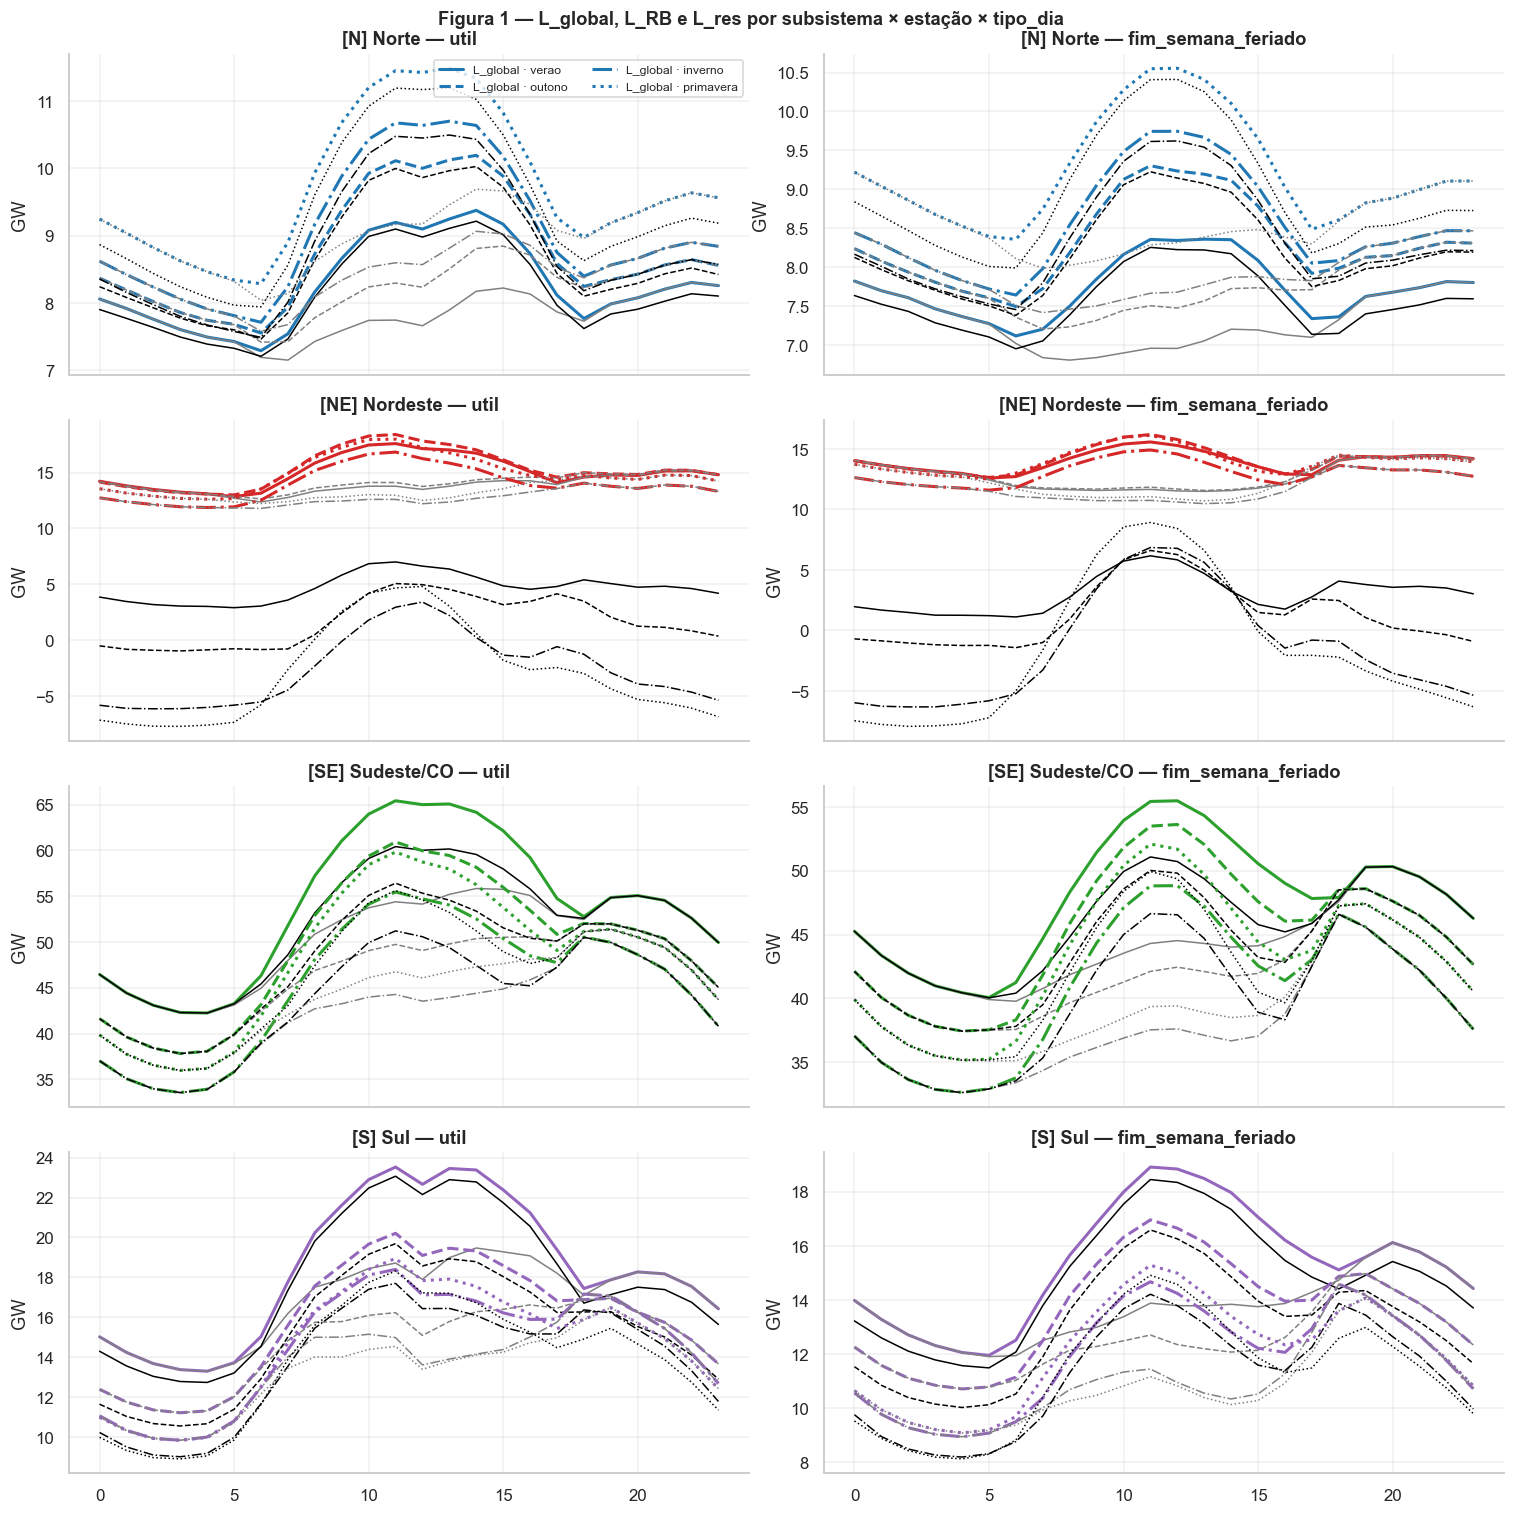

In [7]:
def avg_profile(df, cols, by=("id_subsistema", "estacao", "tipo_dia_g", "hora")):
    return df.groupby(list(by), observed=False)[list(cols)].mean().reset_index()


prof = avg_profile(panel, ["L_global", "L_RB", "L_res", "G_s_total", "G_w_total", "G_h_total"])
prof.to_csv(TABLE_DIR / "tab_perfis_horarios_carga.csv", index=False, float_format="%.1f")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for j, td in enumerate(["util", "fim_semana_feriado"]):
    for i, sub in enumerate(SUBSYS_ORDER):
        ax = axes[i, j]
        for est, ls in zip(SEASON_ORDER, ["-", "--", "-.", ":"]):
            g = prof.query("id_subsistema == @sub and estacao == @est and tipo_dia_g == @td")
            if len(g) == 0: continue
            ax.plot(g["hora"], g["L_global"]/1000, color=SUB_COLOR[sub], ls=ls, lw=2,
                    label=f"L_global · {est}")
            ax.plot(g["hora"], g["L_RB"]/1000,  color="gray",  ls=ls, lw=1)
            ax.plot(g["hora"], g["L_res"]/1000, color="black", ls=ls, lw=1)
        ax.set_title(f"[{sub}] {SUB_LABEL[sub]} — {td}")
        ax.set_ylabel("GW")
        ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8, ncols=2, loc="upper right")
fig.suptitle("Figura 1 — L_global, L_RB e L_res por subsistema × estação × tipo_dia",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_carga_global_rb_res.png", bbox_inches="tight")
plt.show()


## 7. Diagnóstico operacional — Figura 2

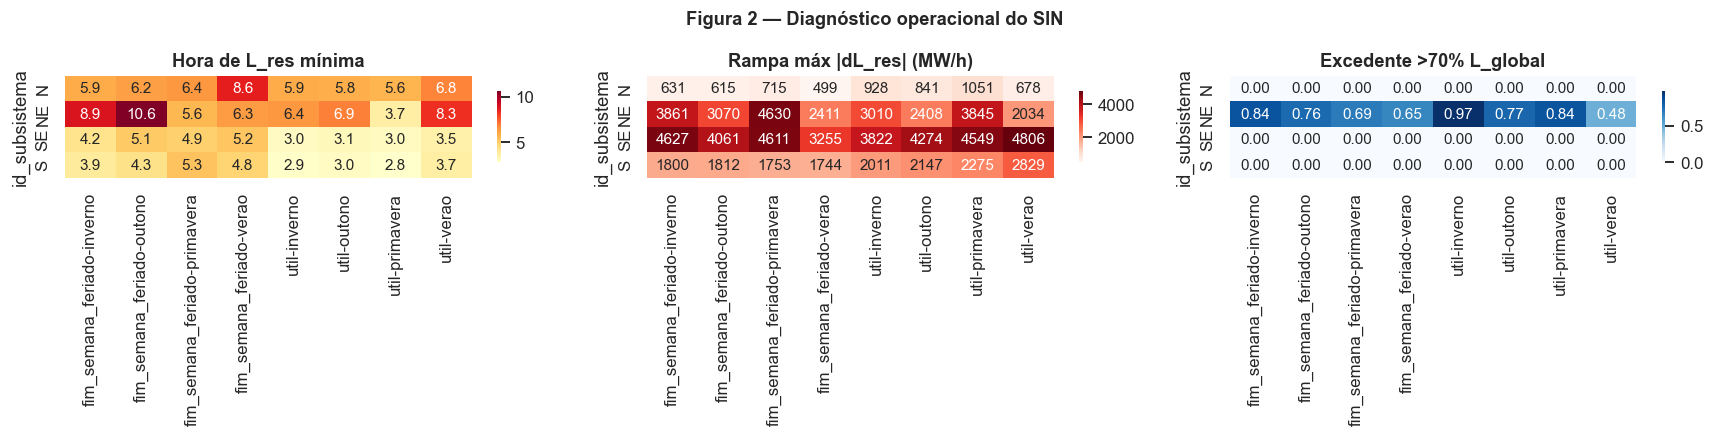

In [8]:
ag = panel.groupby(["id_subsistema", "estacao", "tipo_dia_g", "data"])
hora_min = ag.apply(
    lambda x: x.loc[x["L_res"].idxmin(), "hora"] if x["L_res"].notna().any() else np.nan,
    include_groups=False).reset_index(name="hora_min_L_res")
hora_min_avg = (hora_min.groupby(["id_subsistema", "estacao", "tipo_dia_g"])["hora_min_L_res"]
                .mean().reset_index())
ramp = ag["dL_res"].apply(lambda x: x.abs().max()).reset_index(name="rampa_max_dL_res")
ramp_avg = (ramp.groupby(["id_subsistema", "estacao", "tipo_dia_g"])["rampa_max_dL_res"]
            .mean().reset_index())
d = panel.copy()
d["pot_exc"] = ((d["G_s_total"] + d["G_w_total"]) > 0.7 * d["L_global"]).astype(int)
exc = d.groupby(["id_subsistema", "estacao", "tipo_dia_g"])["pot_exc"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
def heatmap(df, val, title, ax, fmt=".1f", cmap="viridis"):
    piv = (df.pivot_table(index="id_subsistema", columns=["tipo_dia_g", "estacao"], values=val)
              .reindex(index=SUBSYS_ORDER))
    sns.heatmap(piv, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar_kws={"shrink": .7})
    ax.set_title(title); ax.set_xlabel("")
heatmap(hora_min_avg, "hora_min_L_res",     "Hora de L_res mínima",      axes[0], fmt=".1f", cmap="YlOrRd")
heatmap(ramp_avg,     "rampa_max_dL_res",   "Rampa máx |dL_res| (MW/h)", axes[1], fmt=".0f", cmap="Reds")
heatmap(exc,          "pot_exc",            "Excedente >70% L_global",   axes[2], fmt=".2f", cmap="Blues")
fig.suptitle("Figura 2 — Diagnóstico operacional do SIN", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_diagnostico_operacional.png", bbox_inches="tight")
plt.show()


## 8. Curva do pato contrafactual — Figura 4

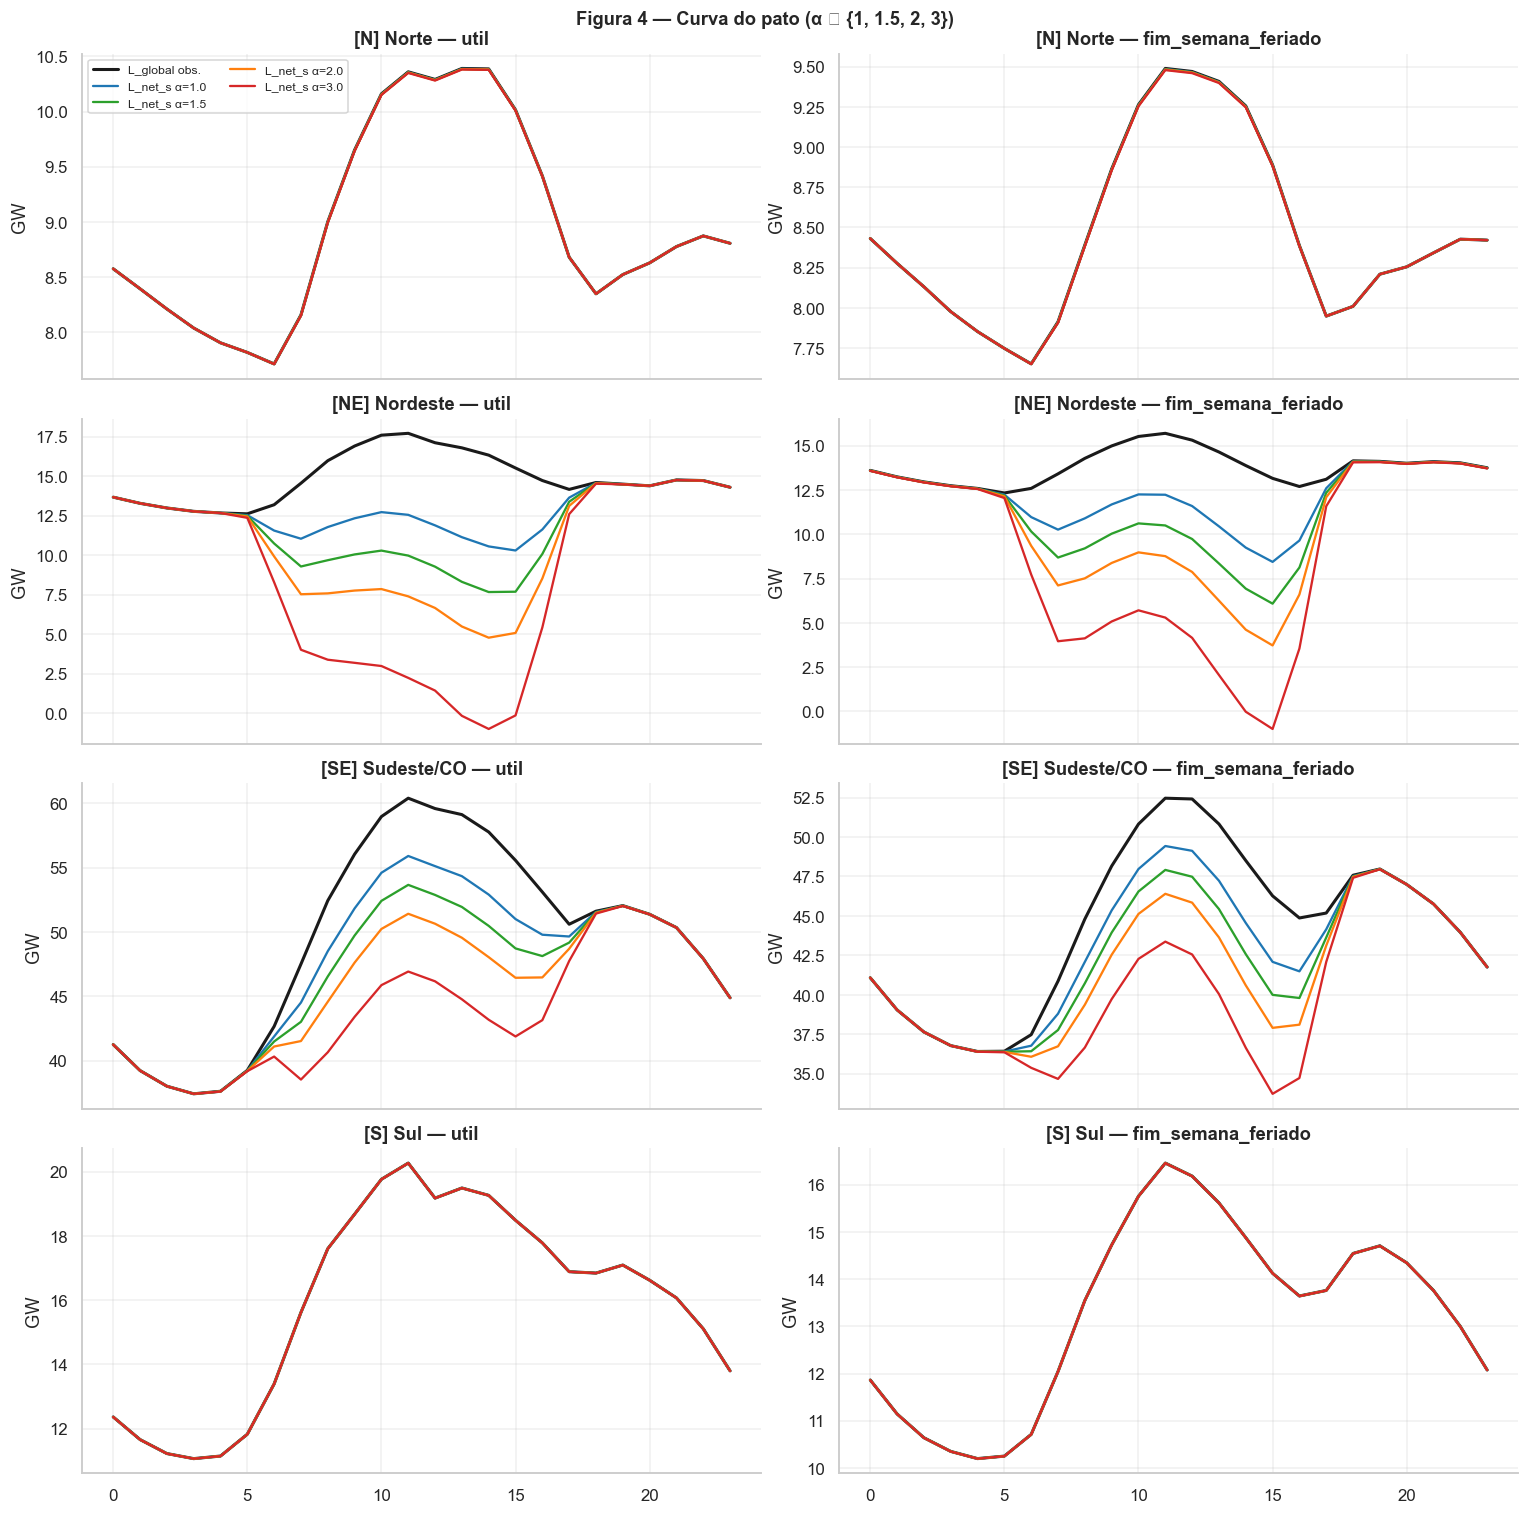

In [9]:
ALPHAS = [1.0, 1.5, 2.0, 3.0]
typ = panel.groupby(["id_subsistema", "estacao", "tipo_dia_g", "hora"], observed=False).agg(
    L_global=("L_global", "mean"),
    G_s_total=("G_s_total", "mean"),
    G_w_total=("G_w_total", "mean"),
    G_h_total=("G_h_total", "mean"),
).reset_index()

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for j, td in enumerate(["util", "fim_semana_feriado"]):
    for i, sub in enumerate(SUBSYS_ORDER):
        ax = axes[i, j]
        g = typ.query("id_subsistema == @sub and tipo_dia_g == @td")
        gp = g.groupby("hora").mean(numeric_only=True).reset_index()
        ax.plot(gp["hora"], gp["L_global"]/1000, "k-", lw=2, label="L_global obs.")
        for alpha, col in zip(ALPHAS, ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
            Ln = gp["L_global"] - alpha * gp["G_s_total"]
            ax.plot(gp["hora"], Ln/1000, color=col, lw=1.5, label=f"L_net_s α={alpha}")
        ax.set_title(f"[{sub}] {SUB_LABEL[sub]} — {td}")
        ax.set_ylabel("GW"); ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8, ncols=2)
fig.suptitle("Figura 4 — Curva do pato (α ∈ {1, 1.5, 2, 3})", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_curva_pato_contrafactual.png", bbox_inches="tight")
plt.show()


## 9. Preços: `CMO_obs`, `PLD_obs`, `PLD_hat`, `lambda_model`

Quatro entidades **distintas**. `PLD_hat` é clip do CMO; `PLD_obs` é NaN (indisponível);
`lambda_model` aparecerá só após o despacho.


In [10]:
PLD_MIN_2025 = 65.69
PLD_MAX_2025 = 939.96

panel = panel.merge(cmo[["din_instante", "id_subsistema", "cmo_h"]],
                    on=["din_instante", "id_subsistema"], how="left")
panel = panel.rename(columns={"cmo_h": "CMO_obs"})
panel["PLD_obs"] = np.nan
panel["PLD_hat"] = panel["CMO_obs"].clip(lower=PLD_MIN_2025, upper=PLD_MAX_2025)

print(panel.groupby("id_subsistema")[["CMO_obs", "PLD_hat"]].describe().round(1).to_string())


              CMO_obs                                                PLD_hat                                               
                count   mean    std  min   25%    50%    75%     max   count   mean    std   min   25%    50%    75%    max
id_subsistema                                                                                                              
N              7272.0  139.8  137.2 -0.1  12.7   56.9  281.9   668.1  7272.0  166.2  112.9  65.7  65.7   65.7  281.9  668.1
NE             7272.0  127.0  134.0 -4.1   1.3   42.2  268.7   668.0  7272.0  156.5  108.0  65.7  65.7   65.7  268.7  668.0
S              7272.0  215.0  132.3 -0.1  96.0  262.6  316.7  1653.2  7272.0  226.2  113.6  65.7  96.0  262.6  316.7  940.0
SE             7272.0  202.7  134.0 -0.0  58.6  251.3  310.0  1652.1  7272.0  215.3  114.4  65.7  65.7  251.3  310.0  940.0


## 10. Fator de captura agregado por métrica (CMO_obs, PLD_obs, PLD_hat)

tag                  F_capture_CMO  F_capture_PLD_hat
id_subsistema fonte                                  
N             solar          0.656              0.771
              wind           1.356              1.245
NE            solar          0.652              0.774
              wind           1.220              1.146
S             solar          0.929              0.940
              wind           1.065              1.052
SE            solar          0.792              0.837
              wind           1.011              0.998


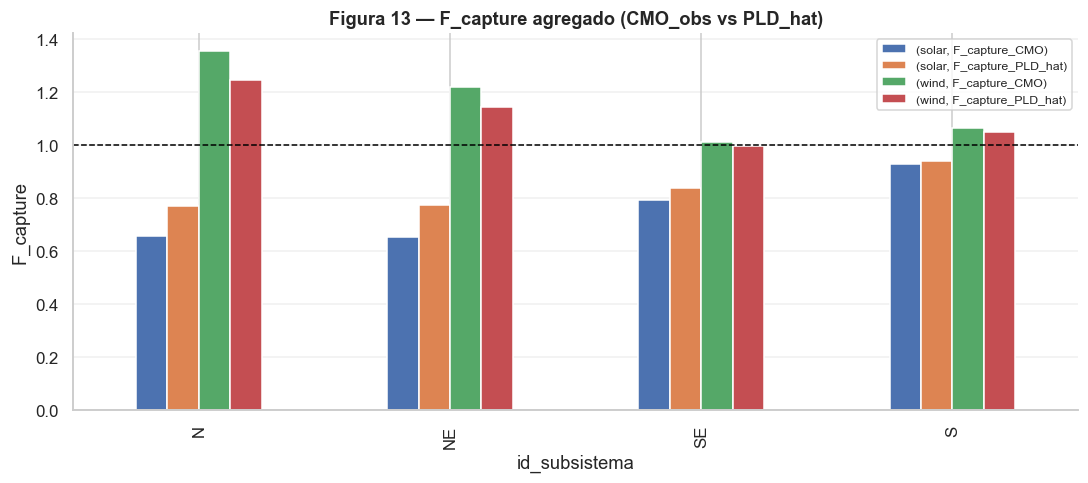

In [11]:
def f_capture(df, sub, gen_col, price_col):
    g = df[(df["id_subsistema"] == sub)].dropna(subset=[price_col, gen_col])
    if len(g) == 0 or g[gen_col].sum() <= 0:
        return np.nan, np.nan, np.nan
    P_avg = float(g[price_col].mean())
    P_cap = float((g[price_col] * g[gen_col]).sum() / g[gen_col].sum())
    return (P_cap / P_avg if P_avg > 0 else np.nan), P_avg, P_cap


records = []
for sub in SUBSYS_ORDER:
    for src, gcol in [("solar", "G_s_total"), ("wind", "G_w_total")]:
        for price_col, tag in [("CMO_obs", "F_capture_CMO"),
                               ("PLD_obs", "F_capture_PLD_obs"),
                               ("PLD_hat", "F_capture_PLD_hat")]:
            Fc, Pavg, Pcap = f_capture(panel, sub, gcol, price_col)
            records.append({"id_subsistema": sub, "fonte": src, "tag": tag,
                            "F_capture": Fc, "P_avg": Pavg, "P_cap": Pcap})
fcap = pd.DataFrame(records)
fcap.to_csv(TABLE_DIR / "tab_fator_captura.csv", index=False, float_format="%.4f")
piv = fcap.pivot_table(index=["id_subsistema", "fonte"], columns="tag", values="F_capture")
print(piv.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
df_plot = (fcap.query("tag in ['F_capture_CMO', 'F_capture_PLD_hat']")
                .pivot_table(index="id_subsistema", columns=["fonte", "tag"], values="F_capture")
                .reindex(SUBSYS_ORDER))
df_plot.plot.bar(ax=ax)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_title("Figura 13 — F_capture agregado (CMO_obs vs PLD_hat)")
ax.set_ylabel("F_capture"); ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig13_fator_captura.png", bbox_inches="tight")
plt.show()


## 11. **NOVO**: Fator de captura por subsistema × fonte × estação × tipo_dia × métrica

Tabela `tab_capture_factors_by_season_daytype.csv` com:
`P_avg_metric`, `P_capture_source`, `F_capture` decompostos por estação e tipo de dia.
Não mistura `CMO_obs`, `PLD_hat`, `PLD_obs` e `lambda_model`.


id_subsistema fonte   estacao tipo_dia price_metric  P_avg_metric  P_capture_source  F_capture
            N solar   inverno  domingo      CMO_obs       164.727            17.111      0.104
            N solar   inverno  feriado      CMO_obs       184.305            33.014      0.179
            N solar   inverno   sabado      CMO_obs       192.586            56.424      0.293
            N solar   inverno     util      CMO_obs       250.368           189.342      0.756
            N solar    outono  domingo      CMO_obs        28.741             1.342      0.047
            N solar    outono  feriado      CMO_obs        30.894             3.472      0.112
            N solar    outono   sabado      CMO_obs        49.204            13.517      0.275
            N solar    outono     util      CMO_obs        68.811            54.400      0.791
            N solar primavera  domingo      CMO_obs       187.269            20.804      0.111
            N solar primavera  feriado      CMO_ob

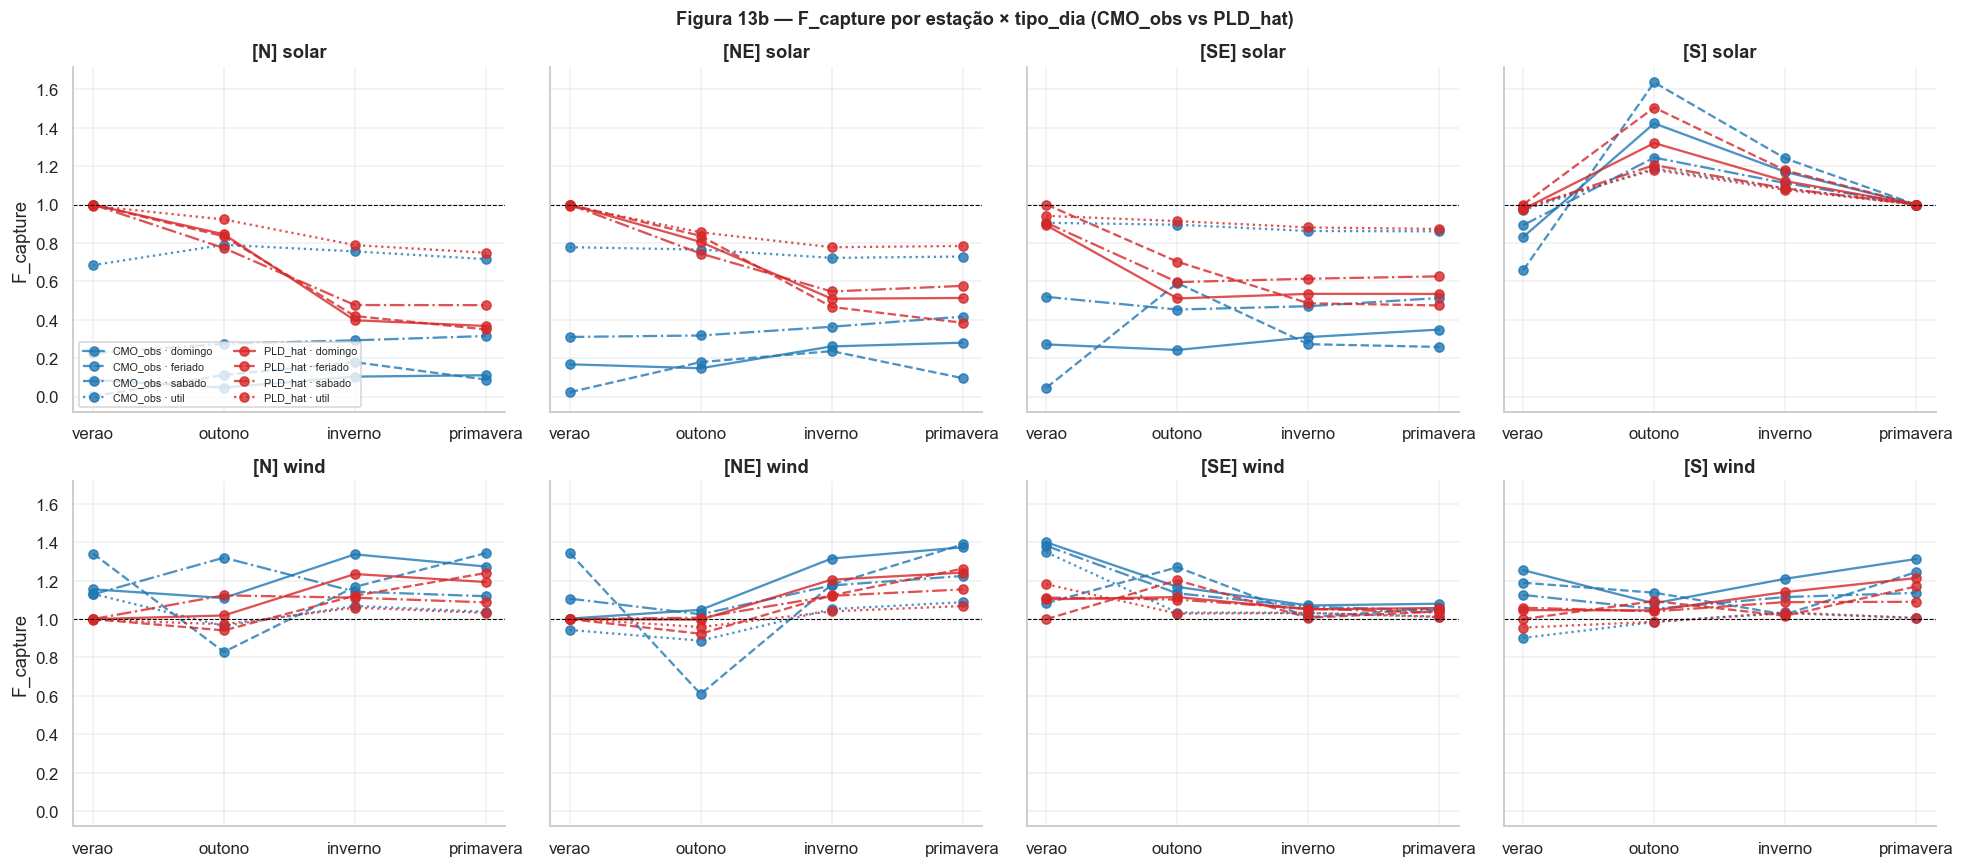

In [12]:
def f_capture_grouped(df, gen_col, price_col, by=("id_subsistema", "estacao", "tipo_dia")):
    rows = []
    for keys, g in df.groupby(list(by), observed=False):
        gd = g.dropna(subset=[price_col, gen_col])
        if len(gd) == 0 or gd[gen_col].sum() <= 0:
            P_avg = P_cap = Fc = np.nan
        else:
            P_avg = float(gd[price_col].mean())
            P_cap = float((gd[price_col] * gd[gen_col]).sum() / gd[gen_col].sum())
            Fc = P_cap / P_avg if P_avg > 0 else np.nan
        row = dict(zip(by, keys if isinstance(keys, tuple) else (keys,)))
        row.update({"price_metric": price_col, "P_avg_metric": P_avg,
                    "P_capture_source": P_cap, "F_capture": Fc})
        rows.append(row)
    return rows


all_rows = []
for src, gcol in [("solar", "G_s_total"), ("wind", "G_w_total")]:
    for price_col in ["CMO_obs", "PLD_obs", "PLD_hat"]:
        rs = f_capture_grouped(panel, gcol, price_col)
        for r in rs:
            r["fonte"] = src
            all_rows.append(r)
fcap_season = pd.DataFrame(all_rows)
fcap_season = fcap_season[["id_subsistema", "fonte", "estacao", "tipo_dia",
                           "price_metric", "P_avg_metric", "P_capture_source", "F_capture"]]
fcap_season.to_csv(TABLE_DIR / "tab_capture_factors_by_season_daytype.csv",
                   index=False, float_format="%.4f")
print(fcap_season.dropna().query("price_metric == 'CMO_obs'").head(12).round(3).to_string(index=False))

# Figura
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
for row, src in enumerate(["solar", "wind"]):
    for col, sub in enumerate(SUBSYS_ORDER):
        ax = axes[row, col]
        for metric, color in [("CMO_obs", "#1f77b4"), ("PLD_hat", "#d62728")]:
            d = fcap_season.query("fonte == @src and id_subsistema == @sub and price_metric == @metric")
            piv = d.pivot_table(index="estacao", columns="tipo_dia", values="F_capture")
            piv = piv.reindex(SEASON_ORDER)
            for td_col, ls in zip(piv.columns, ["-", "--", "-.", ":"]):
                ax.plot(piv.index, piv[td_col], "o-", color=color, ls=ls,
                        lw=1.5, label=f"{metric} · {td_col}", alpha=.8)
        ax.set_title(f"[{sub}] {src}")
        ax.axhline(1.0, color="black", ls="--", lw=.7)
        ax.grid(alpha=.3)
        if col == 0:
            ax.set_ylabel("F_capture")
axes[0, 0].legend(fontsize=7, loc="lower left", ncols=2)
fig.suptitle("Figura 13b — F_capture por estação × tipo_dia (CMO_obs vs PLD_hat)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_capture_factors_by_season_daytype.png", bbox_inches="tight")
plt.show()


## 12. Hidrologia (PROXY)

Sem cota montante/jusante e vazão turbinada por usina, todos os blocos
hidrológicos usam **proxies**: afluência observada (`A_MW`), geração observada
(`G_h_total`) e `vol_util_pct`. Fórmula física $P_h = \eta \cdot \rho \cdot g \cdot h_{liq} \cdot q_{turb}$
fica apenas como referência.

`S_t` no despacho é uma **proxy de energia armazenada em MWh-equivalente**
(não volume físico), construída via `vol_util_pct` mapeado para uma escala
calibrada pela faixa de afluência observada.


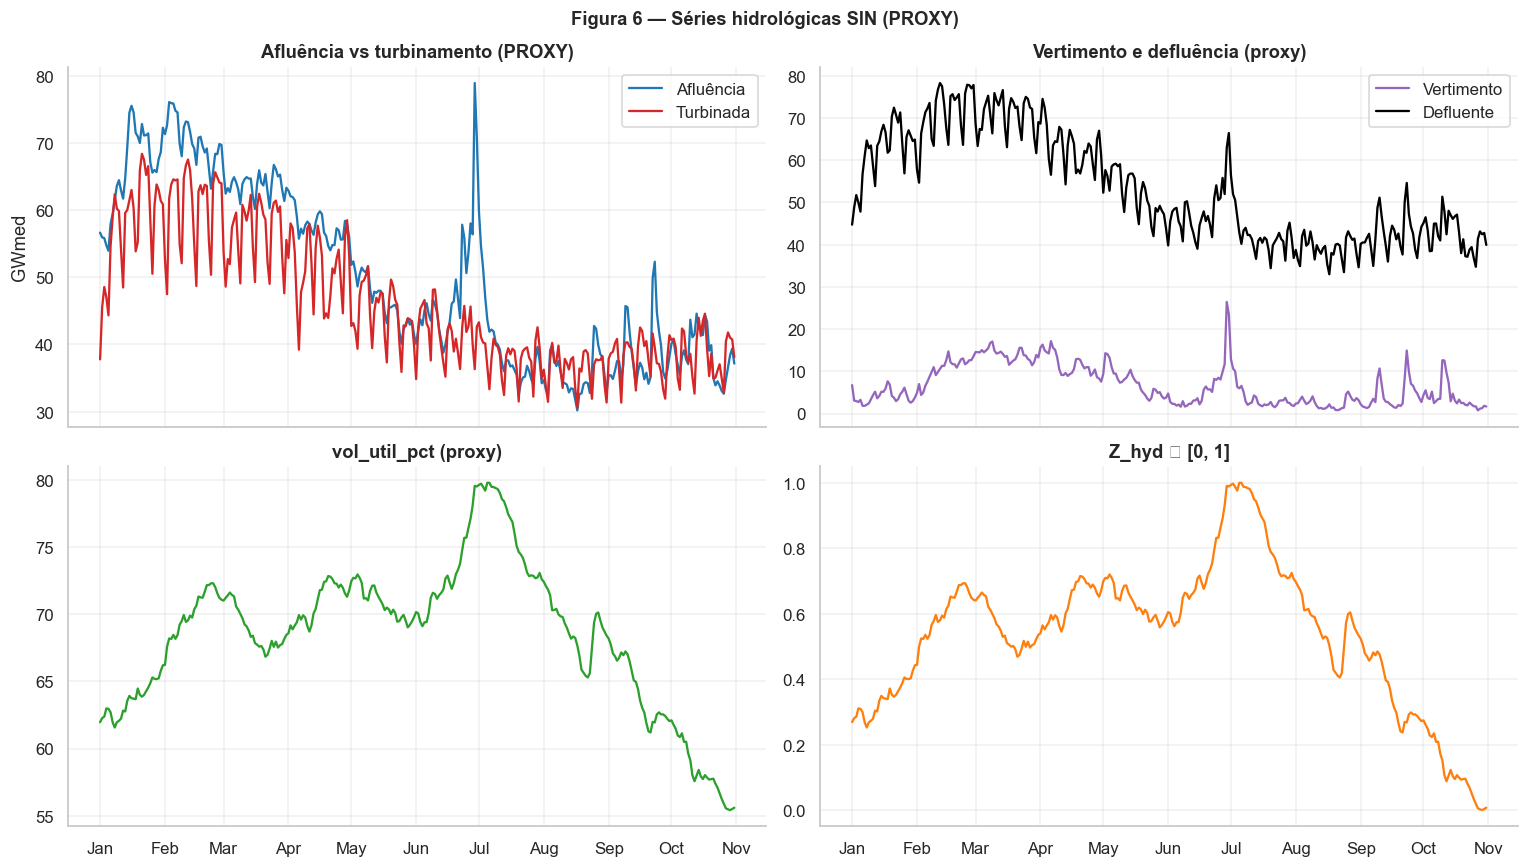

In [13]:
hydro_sin = hydro.copy()
hydro_sin["Storage_MW"] = hydro_sin["A_MW"].cumsum() - hydro_sin["Outflow_MW"].cumsum()
if hydro_sin["vol_util_pct"].notna().any():
    s = hydro_sin["vol_util_pct"]
else:
    s = hydro_sin["Storage_MW"]
hydro_sin["Z_hyd"] = (s - s.min()) / max(s.max() - s.min(), 1e-9)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes[0, 0].plot(hydro_sin["din_instante"], hydro_sin["A_MW"]/1000, label="Afluência", color="#1f77b4")
axes[0, 0].plot(hydro_sin["din_instante"], hydro_sin["T_MW"]/1000, label="Turbinada", color="#d62728")
axes[0, 0].set_title("Afluência vs turbinamento (PROXY)"); axes[0, 0].set_ylabel("GWmed")
axes[0, 0].legend(); axes[0, 0].grid(alpha=.3)
axes[0, 1].plot(hydro_sin["din_instante"], hydro_sin["Spill_MW"]/1000, label="Vertimento", color="#9467bd")
axes[0, 1].plot(hydro_sin["din_instante"], hydro_sin["Outflow_MW"]/1000, label="Defluente", color="black")
axes[0, 1].set_title("Vertimento e defluência (proxy)"); axes[0, 1].legend(); axes[0, 1].grid(alpha=.3)
axes[1, 0].plot(hydro_sin["din_instante"], hydro_sin["vol_util_pct"], color="#2ca02c")
axes[1, 0].set_title("vol_util_pct (proxy)"); axes[1, 0].grid(alpha=.3)
axes[1, 1].plot(hydro_sin["din_instante"], hydro_sin["Z_hyd"], color="#ff7f0e")
axes[1, 1].set_title("Z_hyd ∈ [0, 1]"); axes[1, 1].grid(alpha=.3)
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.suptitle("Figura 6 — Séries hidrológicas SIN (PROXY)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig06_hidrologia_proxy.png", bbox_inches="tight")
plt.show()


## 13. Calibração de parâmetros do despacho

`CMO_obs = c1 + c2 · G_th_total` (térmica **despachável** somente; nuclear não
entra). `K_th_eff_p99` é a capacidade térmica efetiva. Rampa via p99 de `|ΔG_th|`.

`E_hydro_budget` (orçamento diário de energia hidráulica) calibrado para 95%
da geração hidro observada no dia típico, evitando engessamento.


In [14]:
g = panel.dropna(subset=["CMO_obs"]).copy()
y = g["CMO_obs"].values
x = g["G_th_total"].values
A = np.column_stack([np.ones_like(x), x])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
c1_calib = max(float(coef[0]), 50.0)
c2_calib = max(float(coef[1]), 1e-5)

agg_panel = panel.groupby("din_instante", as_index=False).agg(
    L_global=("L_global", "sum"),
    G_s_total=("G_s_total", "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    G_th_total=("G_th_total", "sum"),
    G_nuc_inflex=("G_nuc_inflex", "sum"),
)
K_TH_SIN  = float(np.nanquantile(agg_panel["G_th_total"], 0.995))
K_H_SIN   = float(np.nanquantile(agg_panel["G_h_total"],  0.995))
K_NUC_SIN = float(np.nanquantile(agg_panel["G_nuc_inflex"], 0.995))
dG_th = agg_panel["G_th_total"].diff().abs().dropna()
rho_up = rho_dn = float(np.nanquantile(dG_th, 0.99))

PARAMS = {
    "c1_RS_per_MWh":           round(c1_calib, 2),
    "c2_RS_per_MWh2":          round(c2_calib, 6),
    "K_TH_SIN_MW":             round(K_TH_SIN, 0),
    "K_H_SIN_MW":              round(K_H_SIN, 0),
    "K_NUC_SIN_MW":            round(K_NUC_SIN, 0),
    "rho_up_MW_per_h":         round(rho_up, 0),
    "rho_dn_MW_per_h":         round(rho_dn, 0),
    "pi_curt_RS_per_MWh":      30.0,
    "pi_def_RS_per_MWh":       3500.0,
    "VOLL_RS_per_MWh":         3500.0,
    "water_opportunity_cost":  80.0,
    "shadow_water_value_proxy": 60.0,
}
pd.DataFrame.from_dict(PARAMS, orient="index", columns=["valor"]).to_csv(
    TABLE_DIR / "tab_params_dispatch.csv")
print(pd.DataFrame.from_dict(PARAMS, orient="index", columns=["valor"]).round(3).to_string())


                              valor
c1_RS_per_MWh               123.480
c2_RS_per_MWh2                0.023
K_TH_SIN_MW               13676.000
K_H_SIN_MW                81102.000
K_NUC_SIN_MW               2016.000
rho_up_MW_per_h             683.000
rho_dn_MW_per_h             683.000
pi_curt_RS_per_MWh           30.000
pi_def_RS_per_MWh          3500.000
VOLL_RS_per_MWh            3500.000
water_opportunity_cost       80.000
shadow_water_value_proxy     60.000


## 14. Despacho centralizado com **estado de reservatório `S_t`**

Modelo intra-diário com inflow proxy uniforme (afluência média do dia/24h),
estado `S_t` normalizado em MWh-equivalentes, vertimento `spill_t` e
penalidade `water_opportunity_cost` por uso da água.
Não chamamos de "valor terminal" rigoroso — é um *shadow_water_value_proxy*:
$\min (\text{custos}) - V_S \cdot S_T$.

Balanço com `L_t`:

$G_s + G_w + h + n + G_{nuc} = L + curt - def$

Dinâmica do reservatório:

$S_{t+1} = S_t + \text{inflow}_t - h_t - \text{spill}_t,\quad
S_{\min} \le S_t \le S_{\max},\quad
h_t, \text{spill}_t \ge 0.$

A nuclear `G_{nuc}` entra como **geração inflexível** (constante igual a
`K_NUC` quando o subsistema tem nuclear). Térmica `n_t` é despachável.


In [15]:
@dataclass
class ReservoirSpec:
    S_max: float        # MWh
    S_min: float        # MWh
    S_init: float       # MWh
    inflow: np.ndarray  # MWh por hora (len = T)


def solve_dispatch_with_reservoir(
    L: np.ndarray, G_s: np.ndarray, G_w: np.ndarray, G_nuc: np.ndarray,
    K_T: float, c1: float, c2: float, rho_up: float, rho_dn: float,
    reservoir: ReservoirSpec,
    K_H_inst: float | None = None,
    water_opportunity_cost: float = 80.0,
    shadow_water_value_proxy: float = 60.0,
    pi_curt: float = 30.0, pi_def: float = 3500.0,
) -> dict:
    """Despacho horário com estado de reservatório.

    Variáveis:
      n     — térmica despachável (MW)
      h     — vazão turbinada/uso da água (MW; energia equivalente)
      spill — vertimento (MW)
      S     — estado do reservatório (MWh-equivalente), len T+1
      curt  — curtailment renovável residual (não solar explícito)
      defc  — déficit

    Objetivo:
      thermal_cost + deficit_penalty + curtailment_penalty
      + water_opportunity_cost * sum h
      - shadow_water_value_proxy * S[T]
    """
    T = len(L)
    n     = cp.Variable(T, nonneg=True)
    h     = cp.Variable(T, nonneg=True)
    spill = cp.Variable(T, nonneg=True)
    curt  = cp.Variable(T, nonneg=True)
    defc  = cp.Variable(T, nonneg=True)
    S     = cp.Variable(T + 1, nonneg=True)

    cost = (c1 * cp.sum(n) + 0.5 * c2 * cp.sum_squares(n)
            + pi_curt * cp.sum(curt) + pi_def * cp.sum(defc)
            + water_opportunity_cost * cp.sum(h)
            - shadow_water_value_proxy * S[T])

    bal = (G_s + G_w + G_nuc + h + n) - (L + curt - defc) == 0
    cons = [bal,
            n <= K_T,
            n[1:] - n[:-1] <= rho_up,
            n[:-1] - n[1:] <= rho_dn,
            S[0] == reservoir.S_init,
            S <= reservoir.S_max,
            S >= reservoir.S_min]
    if K_H_inst is not None:
        cons.append(h <= K_H_inst)
    # Dinâmica: S_{t+1} = S_t + inflow_t - h_t - spill_t
    for t in range(T):
        cons.append(S[t + 1] == S[t] + reservoir.inflow[t] - h[t] - spill[t])

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)
    lam = -bal.dual_value if bal.dual_value is not None else np.full(T, np.nan)
    return {
        "status": prob.status, "cost": float(prob.value),
        "n": np.asarray(n.value), "h": np.asarray(h.value),
        "spill": np.asarray(spill.value),
        "curt": np.asarray(curt.value), "deficit": np.asarray(defc.value),
        "S": np.asarray(S.value), "lambda_model": np.asarray(lam),
    }


def typical_day(panel, sub, season, td) -> pd.DataFrame:
    g = panel.query("id_subsistema == @sub and estacao == @season and tipo_dia_g == @td")
    return g.groupby("hora").agg(
        L_global=("L_global", "mean"),
        G_s_total=("G_s_total", "mean"),
        G_w_total=("G_w_total", "mean"),
        G_h_total=("G_h_total", "mean"),
        G_th_total=("G_th_total", "mean"),
        G_nuc_inflex=("G_nuc_inflex", "mean"),
        CMO_obs=("CMO_obs", "mean"),
    ).reindex(range(24))


# Afluência média horária por subsistema (proxy a partir de hidrologia SIN agregada)
# A_MW está em MWmed diário; divide por 4 para distribuir entre 4 subsistemas e usa
# como inflow horário constante (proxy intra-diário).
A_daily_avg = float(hydro_sin["A_MW"].mean())   # MWmed dia
inflow_per_sub_h = A_daily_avg / len(SUBSYS_ORDER)  # MW

rows = []
results_disp = {}
for sub in SUBSYS_ORDER:
    for est in SEASON_ORDER:
        for td in ["util", "fim_semana_feriado"]:
            prof = typical_day(panel, sub, est, td)
            if prof["L_global"].isna().all():
                continue
            prof = prof.ffill().bfill().fillna(0.0)
            L_t   = prof["L_global"].values
            G_s_t = prof["G_s_total"].values
            G_w_t = prof["G_w_total"].values
            G_nuc_t = prof["G_nuc_inflex"].values
            K_T_l = float(K_eff.loc[sub, "K_th_eff_p99"])
            K_H_l = float(K_eff.loc[sub, "K_h_eff_p99"])

            # Reservatório calibrado para SE (principal); demais subsistemas reduzidos
            scale_sub = {"N": 0.8, "NE": 0.6, "SE": 1.0, "S": 0.4}[sub]
            S_max = 24 * K_H_l * 5.0 * scale_sub   # ~5 dias de turbinamento à K_H
            S_min = 0.0
            S_init = 0.5 * S_max
            inflow_h = np.full(24, inflow_per_sub_h * scale_sub)
            reservoir = ReservoirSpec(S_max=S_max, S_min=S_min,
                                      S_init=S_init, inflow=inflow_h)
            d_th  = panel.loc[panel["id_subsistema"] == sub, "G_th_total"].diff().abs()
            rho_l = float(np.nanquantile(d_th.dropna(), 0.99))

            res = solve_dispatch_with_reservoir(
                L_t, G_s_t, G_w_t, G_nuc_t, K_T=K_T_l,
                c1=PARAMS["c1_RS_per_MWh"], c2=PARAMS["c2_RS_per_MWh2"],
                rho_up=rho_l, rho_dn=rho_l,
                reservoir=reservoir, K_H_inst=K_H_l,
                water_opportunity_cost=PARAMS["water_opportunity_cost"],
                shadow_water_value_proxy=PARAMS["shadow_water_value_proxy"],
                pi_curt=PARAMS["pi_curt_RS_per_MWh"],
                pi_def=PARAMS["pi_def_RS_per_MWh"],
            )
            results_disp[(sub, est, td)] = res
            rows.append({
                "subsistema": sub, "estacao": est, "tipo_dia": td,
                "status": res["status"], "cost": res["cost"],
                "G_th_dispatched": float(res["n"].sum()),
                "G_h_used": float(res["h"].sum()),
                "spill_total": float(res["spill"].sum()),
                "S_T_residual": float(res["S"][-1]),
                "curt_total": float(res["curt"].sum()),
                "deficit_total": float(res["deficit"].sum()),
                "lambda_model_mean": float(np.nanmean(res["lambda_model"])),
                "CMO_obs_mean": float(np.nanmean(prof["CMO_obs"])),
            })
disp_summary = pd.DataFrame(rows)
disp_summary.to_csv(TABLE_DIR / "tab_despacho_centralizado.csv", index=False, float_format="%.2f")
print(disp_summary.round(1).to_string(index=False))


subsistema   estacao           tipo_dia  status        cost  G_th_dispatched  G_h_used  spill_total  S_T_residual  curt_total  deficit_total  lambda_model_mean  CMO_obs_mean
         N     verao               util optimal -41419609.3          16926.2  178544.6          0.0      965550.6         0.0            0.0              140.0          19.4
         N     verao fim_semana_feriado optimal -43375733.5          16926.2  164572.3          0.0      979522.9         0.0            0.0              140.0          13.0
         N    outono               util optimal -39732189.9          16926.2  190597.6          0.0      953497.6         0.0            0.0              140.0          68.8
         N    outono fim_semana_feriado optimal -41244369.8          16926.2  179796.3          0.0      964298.9         0.0            0.0              140.0          38.0
         N   inverno               util optimal -39066422.8          16926.2  195353.1          0.0      948742.1         0.0     

### Figura 7 — Despacho com reservatório (SE, verão, dia útil)

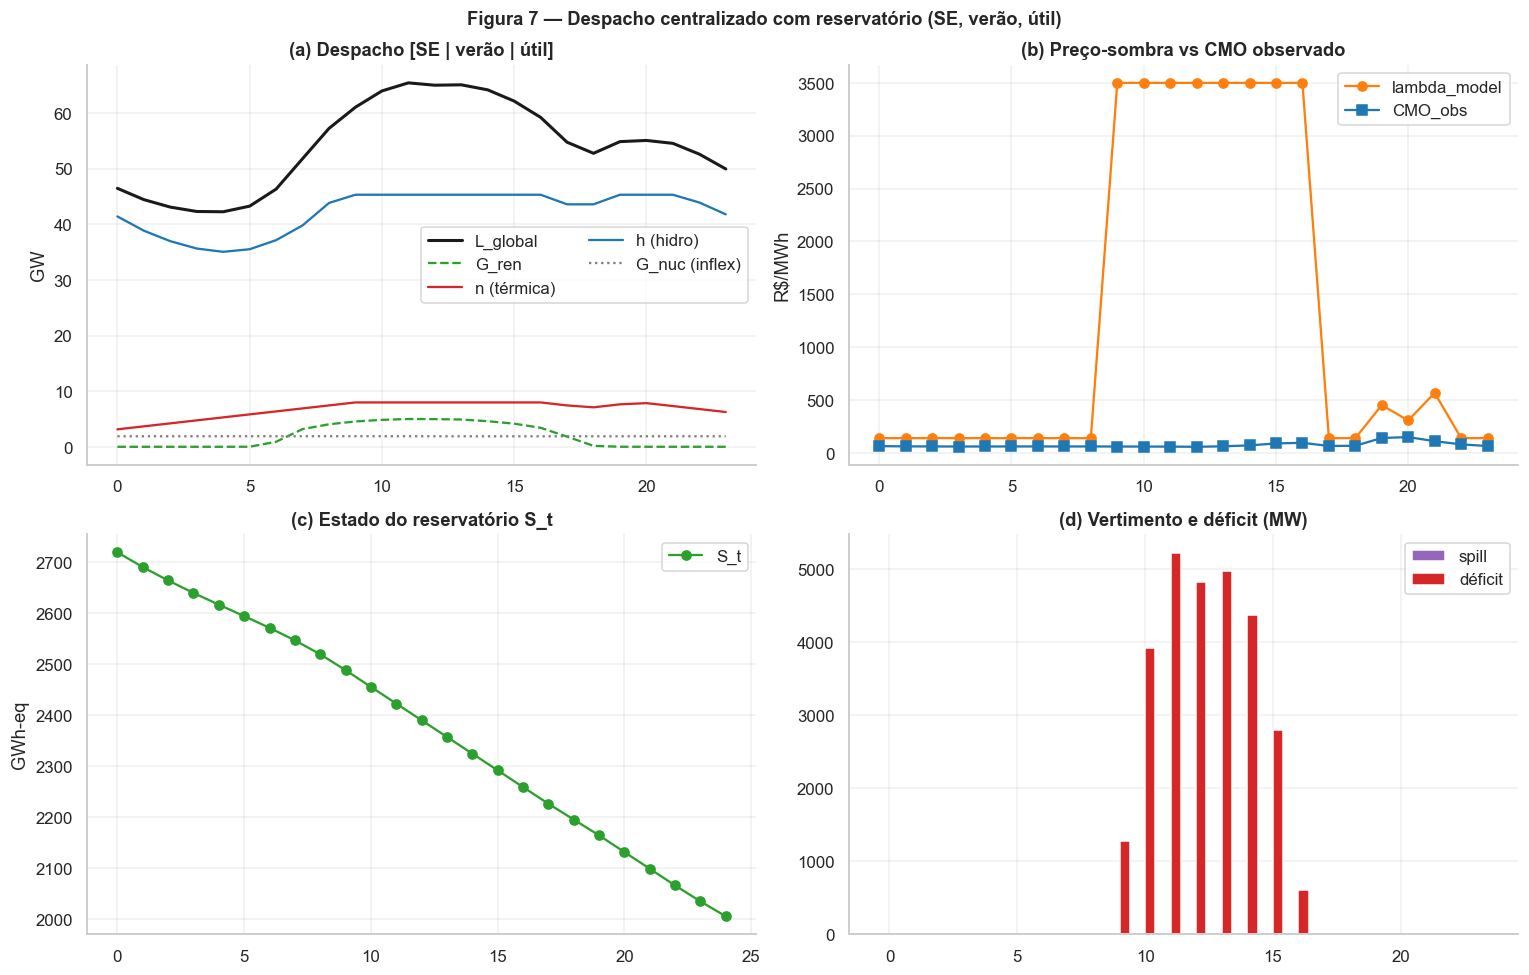

In [16]:
key = ("SE", "verao", "util")
if key in results_disp:
    r = results_disp[key]
    prof = typical_day(panel, *key).ffill().bfill().fillna(0.0)
    hours = np.arange(24)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ax = axes[0, 0]
    ax.plot(hours, prof["L_global"]/1000, "k-", lw=2, label="L_global")
    ax.plot(hours, (prof["G_s_total"] + prof["G_w_total"])/1000, "--", color="#2ca02c", label="G_ren")
    ax.plot(hours, r["n"]/1000, color="#d62728", label="n (térmica)")
    ax.plot(hours, r["h"]/1000, color="#1f77b4", label="h (hidro)")
    ax.plot(hours, prof["G_nuc_inflex"]/1000, color="#7f7f7f", ls=":", label="G_nuc (inflex)")
    ax.set_title("(a) Despacho [SE | verão | útil]"); ax.set_ylabel("GW")
    ax.legend(ncols=2); ax.grid(alpha=.3)

    ax = axes[0, 1]
    ax.plot(hours, r["lambda_model"], "o-", color="#ff7f0e", label="lambda_model")
    ax.plot(hours, prof["CMO_obs"],   "s-", color="#1f77b4", label="CMO_obs")
    ax.set_title("(b) Preço-sombra vs CMO observado"); ax.set_ylabel("R$/MWh")
    ax.legend(); ax.grid(alpha=.3)

    ax = axes[1, 0]
    ax.plot(np.arange(len(r["S"])), r["S"]/1000, "-o", color="#2ca02c", label="S_t")
    ax.set_title("(c) Estado do reservatório S_t"); ax.set_ylabel("GWh-eq")
    ax.legend(); ax.grid(alpha=.3)

    ax = axes[1, 1]
    ax.bar(hours - 0.2, r["spill"], width=0.4, color="#9467bd", label="spill")
    ax.bar(hours + 0.2, r["deficit"], width=0.4, color="#d62728", label="déficit")
    ax.set_title("(d) Vertimento e déficit (MW)"); ax.legend(); ax.grid(alpha=.3)

    fig.suptitle("Figura 7 — Despacho centralizado com reservatório (SE, verão, útil)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig07_despacho_dia_tipico_SE.png", bbox_inches="tight")
    plt.show()


## 15. Modelo situacional — reescrito

**Correções v3**:

1. `Rev_i_model = ∑_t λ_t · g_i,t` (receita total, R$).
   `R_cap_i_model = Rev_i_model / ∑_t g_i,t` (receita capturada por MWh).
   `F_capture_i_model = R_cap_i_model / mean(λ)`.
2. **Curtailment solar explícito** por agente:
   `g_i + curt_solar_i == K_i · a_s,t` com `g_i, curt_solar_i ≥ 0`.
3. **Nuclear inflexível** entra como `G_nuc(t)` no balanço; nunca somada à térmica.
4. Diagnóstico de factibilidade `tab_feasibility_diagnostics.csv`.


In [17]:
# Templates SIN — 8 dias típicos (4 estações × 2 tipos de dia)
agg = panel.groupby("din_instante", as_index=False).agg(
    L_global=("L_global", "sum"),
    G_s_total=("G_s_total", "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    G_th_total=("G_th_total", "sum"),
    G_nuc_inflex=("G_nuc_inflex", "sum"),
)
agg = add_calendar(agg)
typ_sin = (agg.groupby(["estacao", "tipo_dia_g", "hora"], observed=False)
              .agg(L=("L_global", "mean"),
                   Gs=("G_s_total", "mean"),
                   Gw=("G_w_total", "mean"),
                   Gh=("G_h_total", "mean"),
                   Gth=("G_th_total", "mean"),
                   Gnuc=("G_nuc_inflex", "mean"))
              .reindex(pd.MultiIndex.from_product(
                  [SEASON_ORDER, ["util", "fim_semana_feriado"], range(24)],
                  names=["estacao", "tipo_dia_g", "hora"]))
              .ffill().bfill()
              .reset_index())

blocks = []
for est in SEASON_ORDER:
    for td in ["util", "fim_semana_feriado"]:
        d = typ_sin.query("estacao == @est and tipo_dia_g == @td").sort_values("hora").copy()
        d["bloco"] = f"{est}-{td}"
        blocks.append(d)
template = pd.concat(blocks, ignore_index=True)
T_SIT = len(template)
N_BLOCKS = T_SIT // 24

K_S_SIT  = float(K_eff.loc[:, "K_s_eff_p99"].sum())
K_W_SIT  = float(K_eff.loc[:, "K_w_eff_p99"].sum())
K_TH_SIT = float(K_eff.loc[:, "K_th_eff_p99"].sum())
K_NUC_SIT = float(K_eff.loc[:, "K_nuc_eff_p99"].sum())
K_H_SIT_inst = float(K_eff.loc[:, "K_h_eff_p99"].sum())

a_s_t = (template["Gs"].values / max(K_S_SIT, 1e-6)).clip(0, 1.5)
a_w_t = (template["Gw"].values / max(K_W_SIT, 1e-6)).clip(0, 1.5)
Gw_exog = a_w_t * K_W_SIT
G_nuc_t = template["Gnuc"].values
L_t_sit = template["L"].values

# Orçamento hidráulico diário (≈100% obs para evitar deficit artefatual)
B_h_daily = float(template.groupby("bloco")["Gh"].sum().mean())

# Reservatório SIN agregado
# A_MW está em MWmed (potência média diária); o inflow horário em MW é o próprio A_MW
# (energia diária = A_MW · 24, energia horária = A_MW · 1).
A_total_per_hour = A_daily_avg     # MW de inflow horário (~55.6 GW para o SIN)
inflow_h_sit = np.tile(np.full(24, A_total_per_hour), N_BLOCKS)
# Reservatório dimensionado para acomodar ~10 dias de turbinamento à K_H_SIT_inst
S_max_sit = 24 * K_H_SIT_inst * 10.0
S_init_sit = 0.5 * S_max_sit

print(f"T_SIT={T_SIT}h | N_BLOCKS={N_BLOCKS}")
print(f"K_S_SIT={K_S_SIT/1000:.1f}GW | K_TH_SIT={K_TH_SIT/1000:.1f}GW | "
      f"K_H_SIT={K_H_SIT_inst/1000:.1f}GW | K_NUC_SIT={K_NUC_SIT/1000:.1f}GW")
print(f"a_s_t mean={a_s_t.mean():.3f} | a_w_t mean={a_w_t.mean():.3f}")

# Calibração de c1, c2 baseada apenas em G_th_total (não nuclear)
y_sit = panel.dropna(subset=["CMO_obs"])["CMO_obs"].values
x_sit = panel.dropna(subset=["CMO_obs"])["G_th_total"].values
A_lst = np.column_stack([np.ones_like(x_sit), x_sit])
cf_sit, *_ = np.linalg.lstsq(A_lst, y_sit, rcond=None)
c1_sit = max(float(cf_sit[0]), 50.0)
c2_sit = max(float(cf_sit[1]), 1e-6)
print(f"c1_sit={c1_sit:.1f} | c2_sit={c2_sit:.6f}")


T_SIT=192h | N_BLOCKS=8
K_S_SIT=13.5GW | K_TH_SIT=16.5GW | K_H_SIT=85.7GW | K_NUC_SIT=2.0GW
a_s_t mean=0.258 | a_w_t mean=0.544
c1_sit=123.5 | c2_sit=0.023424


In [18]:
def solve_situational(K1: float, kappa: float = 0.0,
                      hyd_scale: float = 1.0) -> dict:
    """Modelo situacional finito com curtailment solar e nuclear inflexível.

    Estrutura:
      - 2 solares (incumbente K1, entrante K2 = kappa * K1).
      - 1 térmica despachável (c1, c2, K_TH_SIT, rampa rho).
      - 1 hidrelétrica com reservatório S_t e water_opportunity_cost.
      - eólica e nuclear como geração exógena/inflexível.

    Balanço:
      g1 + g2 + Gw_exog + h + n + G_nuc = L + curt_resid - deficit

    Curt solar (por agente):
      g_i + curt_solar_i = K_i * a_s_t
    """
    T = T_SIT
    K2 = kappa * K1
    g1       = cp.Variable(T, nonneg=True)
    g2       = cp.Variable(T, nonneg=True)
    curt1    = cp.Variable(T, nonneg=True)
    curt2    = cp.Variable(T, nonneg=True)
    n        = cp.Variable(T, nonneg=True)
    h        = cp.Variable(T, nonneg=True)
    spill    = cp.Variable(T, nonneg=True)
    curt_res = cp.Variable(T, nonneg=True)
    defc     = cp.Variable(T, nonneg=True)
    S        = cp.Variable(T + 1, nonneg=True)

    cost = (c1_sit * cp.sum(n) + 0.5 * c2_sit * cp.sum_squares(n)
            + PARAMS["water_opportunity_cost"] * cp.sum(h)
            + PARAMS["pi_curt_RS_per_MWh"] * (cp.sum(curt1) + cp.sum(curt2) + cp.sum(curt_res))
            + PARAMS["pi_def_RS_per_MWh"] * cp.sum(defc)
            - PARAMS["shadow_water_value_proxy"] * S[T])

    bal = (g1 + g2 + Gw_exog + h + n + G_nuc_t) - (L_t_sit + curt_res - defc) == 0

    cons = [
        bal,
        g1 + curt1 == K1 * a_s_t,
        g2 + curt2 == K2 * a_s_t,
        n <= K_TH_SIT,
        h <= K_H_SIT_inst * hyd_scale,
        S[0] == S_init_sit,
        S <= S_max_sit * hyd_scale,
    ]
    for t in range(T):
        cons.append(S[t + 1] == S[t] + inflow_h_sit[t] * hyd_scale - h[t] - spill[t])
    for kbl in range(N_BLOCKS):
        cons.append(cp.sum(h[kbl*24:(kbl+1)*24]) <= B_h_daily * hyd_scale)

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)
    lam = -bal.dual_value if bal.dual_value is not None else np.full(T, np.nan)

    G1 = np.asarray(g1.value); G2 = np.asarray(g2.value)
    CU1 = np.asarray(curt1.value); CU2 = np.asarray(curt2.value)
    # Receitas: total vs capturada/MWh
    Rev_1_model = float((lam * G1).sum())
    Rev_2_model = float((lam * G2).sum())
    R_cap_1_model = Rev_1_model / max(G1.sum(), 1e-9)
    R_cap_2_model = Rev_2_model / max(G2.sum(), 1e-9)
    P_avg = float(np.nanmean(lam))
    F_capture_1_model = R_cap_1_model / max(P_avg, 1e-9)
    F_capture_2_model = R_cap_2_model / max(P_avg, 1e-9)
    return {
        "status": prob.status, "cost": float(prob.value),
        "g1": G1, "g2": G2,
        "curt_solar_1": CU1, "curt_solar_2": CU2,
        "n": np.asarray(n.value), "h": np.asarray(h.value),
        "spill": np.asarray(spill.value),
        "curt_resid": np.asarray(curt_res.value),
        "deficit": np.asarray(defc.value),
        "S": np.asarray(S.value),
        "lambda_model": np.asarray(lam),
        "K1": K1, "K2": K2,
        "Rev_1_model": Rev_1_model, "Rev_2_model": Rev_2_model,
        "R_cap_1_model": R_cap_1_model, "R_cap_2_model": R_cap_2_model,
        "F_capture_1_model": F_capture_1_model, "F_capture_2_model": F_capture_2_model,
        "P_avg_lambda": P_avg,
        "curt_rate_1": float(CU1.sum() / max((K1 * a_s_t).sum(), 1e-9)),
        "curt_rate_2": float(CU2.sum() / max((K2 * a_s_t).sum(), 1e-9)) if K2 > 0 else 0.0,
    }


KAPPAS = [0.0, 0.25, 0.5, 1.0, 2.0]
results_sit = {k: solve_situational(K_S_SIT, k) for k in KAPPAS}

rows = []
for k, r in results_sit.items():
    rows.append({
        "kappa": k,
        "cost":               r["cost"],
        "G_th_total":         float(r["n"].sum()),
        "G_h_used":           float(r["h"].sum()),
        "spill_total":        float(r["spill"].sum()),
        "S_T_residual":       float(r["S"][-1]),
        "curt_solar_1":       float(r["curt_solar_1"].sum()),
        "curt_solar_2":       float(r["curt_solar_2"].sum()),
        "curt_solar_total":   float(r["curt_solar_1"].sum() + r["curt_solar_2"].sum()),
        "curt_rate_1":        r["curt_rate_1"],
        "curt_rate_2":        r["curt_rate_2"],
        "curt_resid_total":   float(r["curt_resid"].sum()),
        "deficit_total":      float(r["deficit"].sum()),
        "lambda_model_mean":  r["P_avg_lambda"],
        "Rev_1_model":        r["Rev_1_model"],
        "Rev_2_model":        r["Rev_2_model"],
        "R_cap_1_model":      r["R_cap_1_model"],
        "R_cap_2_model":      r["R_cap_2_model"],
        "F_capture_1_model":  r["F_capture_1_model"],
        "F_capture_2_model":  r["F_capture_2_model"],
    })
sit_summary = pd.DataFrame(rows)
sit_summary.to_csv(TABLE_DIR / "tab_situacional_kappa.csv", index=False, float_format="%.4f")
print(sit_summary.round(3).to_string(index=False))


 kappa         cost  G_th_total    G_h_used  spill_total  S_T_residual  curt_solar_1  curt_solar_2  curt_solar_total  curt_rate_1  curt_rate_2  curt_resid_total  deficit_total  lambda_model_mean  Rev_1_model  Rev_2_model  R_cap_1_model  R_cap_2_model  F_capture_1_model  F_capture_2_model
  0.00 4.084853e+09 2536434.815 8729082.275        1.244  11215888.542         0.006         0.000             0.006          0.0          0.0             0.006     944494.732           2302.252 1.628168e+09 0.000000e+00       2444.477        937.093              1.062              0.407
  0.25 3.738847e+09 2461197.709 8729082.276        0.023  11215889.763         0.001         0.001             0.001          0.0          0.0             0.001     853216.843           1919.211 1.360314e+09 3.400785e+08       2042.330       2042.330              1.064              1.064
  0.50 3.399519e+09 2384229.286 8729082.275        0.488  11215889.298         0.004         0.004             0.008          0.0    

### 15.1 Diagnóstico de factibilidade e déficit

Tabela `tab_feasibility_diagnostics.csv` por cenário: carga total, geração
disponível por fonte, capacidade térmica efetiva, orçamento hidráulico,
geração inflexível, déficit total, horas com déficit, `lambda_model` médio
e máximo.

Se algum cenário gera déficit > 0 com folga térmica + hidro disponíveis,
isso é artefato de modelagem (rampa muito apertada, orçamento muito baixo,
penalidade mal calibrada). Se a infactibilidade é genuína (carga supera
capacidade física agregada), rotulamos como **cenário de estresse**.


In [19]:
diag_rows = []
for k, r in results_sit.items():
    L_total = float(L_t_sit.sum())
    Gs_disp = float((K_S_SIT * a_s_t).sum() + r["K2"] * a_s_t.sum())
    Gw_disp = float(Gw_exog.sum())
    G_nuc_disp = float(G_nuc_t.sum())
    K_TH_eff_total = K_TH_SIT * T_SIT
    B_h_total = B_h_daily * N_BLOCKS
    deficit_h = int((r["deficit"] > 1.0).sum())
    deficit_total = float(r["deficit"].sum())
    cap_supply = (K_TH_eff_total + B_h_total + Gs_disp + Gw_disp + G_nuc_disp)
    # Etiquetagem em 3 níveis:
    #   ok                    : sem déficit
    #   modelagem_artefato    : déficit > 0 mas supply agregado >= demanda
    #                            (deficit vem de descasamento intra-hora: pico solar
    #                            no meio-dia, pico de carga à noite, etc.)
    #   estresse_estrutural   : supply agregado < demanda
    if deficit_total < 1e3:
        lbl = "ok"
    elif cap_supply >= L_total:
        lbl = "modelagem_artefato"
    else:
        lbl = "estresse_estrutural"
    diag_rows.append({
        "scenario": f"kappa={k}",
        "L_total_MWh":        L_total,
        "Gs_avail_MWh":       Gs_disp,
        "Gw_avail_MWh":       Gw_disp,
        "G_nuc_inflex_MWh":   G_nuc_disp,
        "K_th_eff_total_MWh": K_TH_eff_total,
        "E_hydro_budget_MWh": B_h_total,
        "supply_agg_MWh":     cap_supply,
        "supply_minus_load":  cap_supply - L_total,
        "deficit_total_MWh":  deficit_total,
        "deficit_hours":      deficit_h,
        "lambda_mean":        float(np.nanmean(r["lambda_model"])),
        "lambda_max":         float(np.nanmax(r["lambda_model"])),
        "label":              lbl,
    })
diag = pd.DataFrame(diag_rows)
diag.to_csv(TABLE_DIR / "tab_feasibility_diagnostics.csv", index=False, float_format="%.2f")
print(diag.round(0).to_string(index=False))

n_stress = int((diag["label"] == "estresse_estrutural").sum())
n_artefato = int((diag["label"] == "modelagem_artefato").sum())
if n_stress > 0:
    print(f"\n[INFO] {n_stress} cenário(s) com `estresse_estrutural` (supply agregado < demanda).")
if n_artefato > 0:
    print(f"[INFO] {n_artefato} cenário(s) com `modelagem_artefato` "
          "(supply agregado >= demanda, mas descasamento intra-hora gera déficit residual).")


  scenario  L_total_MWh  Gs_avail_MWh  Gw_avail_MWh  G_nuc_inflex_MWh  K_th_eff_total_MWh  E_hydro_budget_MWh  supply_agg_MWh  supply_minus_load  deficit_total_MWh  deficit_hours  lambda_mean  lambda_max               label
 kappa=0.0   15743772.0      666060.0     2522495.0          345206.0           3160591.0           8729082.0      15423433.0          -320339.0           944495.0            118       2302.0      3500.0 estresse_estrutural
kappa=0.25   15743772.0      832575.0     2522495.0          345206.0           3160591.0           8729082.0      15589948.0          -153824.0           853217.0             96       1919.0      3500.0 estresse_estrutural
 kappa=0.5   15743772.0      999090.0     2522495.0          345206.0           3160591.0           8729082.0      15756463.0            12691.0           763670.0             96       1910.0      3500.0  modelagem_artefato
 kappa=1.0   15743772.0     1332120.0     2522495.0          345206.0           3160591.0           8729

### 15.2 Figura 9 — Sensibilidade do situacional a κ

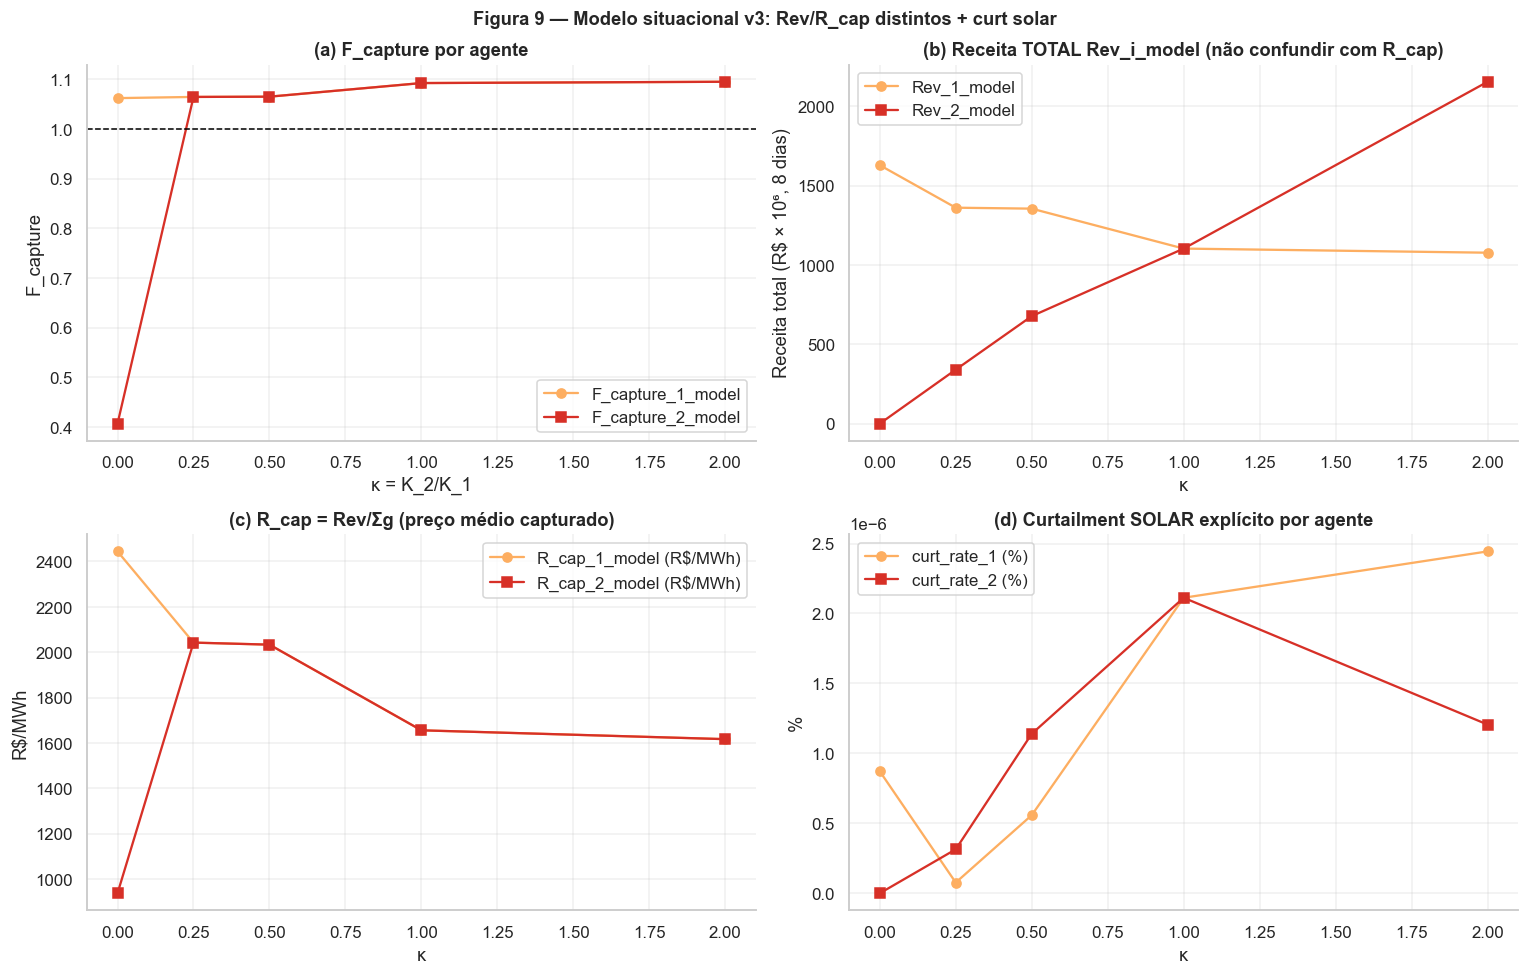

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(sit_summary["kappa"], sit_summary["F_capture_1_model"], "o-", color="#fdae61", label="F_capture_1_model")
ax.plot(sit_summary["kappa"], sit_summary["F_capture_2_model"], "s-", color="#d73027", label="F_capture_2_model")
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xlabel("κ = K_2/K_1"); ax.set_ylabel("F_capture")
ax.set_title("(a) F_capture por agente"); ax.legend(); ax.grid(alpha=.3)

ax = axes[0, 1]
ax.plot(sit_summary["kappa"], sit_summary["Rev_1_model"]/1e6, "o-", color="#fdae61", label="Rev_1_model")
ax.plot(sit_summary["kappa"], sit_summary["Rev_2_model"]/1e6, "s-", color="#d73027", label="Rev_2_model")
ax.set_xlabel("κ"); ax.set_ylabel("Receita total (R$ × 10⁶, 8 dias)")
ax.set_title("(b) Receita TOTAL Rev_i_model (não confundir com R_cap)")
ax.legend(); ax.grid(alpha=.3)

ax = axes[1, 0]
ax.plot(sit_summary["kappa"], sit_summary["R_cap_1_model"], "o-", color="#fdae61", label="R_cap_1_model (R$/MWh)")
ax.plot(sit_summary["kappa"], sit_summary["R_cap_2_model"], "s-", color="#d73027", label="R_cap_2_model (R$/MWh)")
ax.set_xlabel("κ"); ax.set_ylabel("R$/MWh")
ax.set_title("(c) R_cap = Rev/Σg (preço médio capturado)")
ax.legend(); ax.grid(alpha=.3)

ax = axes[1, 1]
ax.plot(sit_summary["kappa"], 100*sit_summary["curt_rate_1"], "o-", color="#fdae61", label="curt_rate_1 (%)")
ax.plot(sit_summary["kappa"], 100*sit_summary["curt_rate_2"], "s-", color="#d73027", label="curt_rate_2 (%)")
ax.set_xlabel("κ"); ax.set_ylabel("%")
ax.set_title("(d) Curtailment SOLAR explícito por agente")
ax.legend(); ax.grid(alpha=.3)

fig.suptitle("Figura 9 — Modelo situacional v3: Rev/R_cap distintos + curt solar",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig09_situacional_sensibilidade.png", bbox_inches="tight")
plt.show()


## 16. Sensibilidade hidrológica (cenários seca/base/úmida)

     cenario  cost (R$ x10^6)  G_th_total (GWh)  G_h_used (GWh)  spill (GWh)  curt_solar_total (GWh)  deficit (MWh)  lambda_model_mean (R$/MWh)
 seca (-30%)         10028.78           3140.55         6110.36       250.40                    0.05     2626158.05                     3120.63
        base          3399.52           2384.23         8729.08         0.00                    0.00      763670.29                     1909.82
umida (+30%)           788.52            986.92        10810.47      1787.39                    0.65       80687.84                      607.79


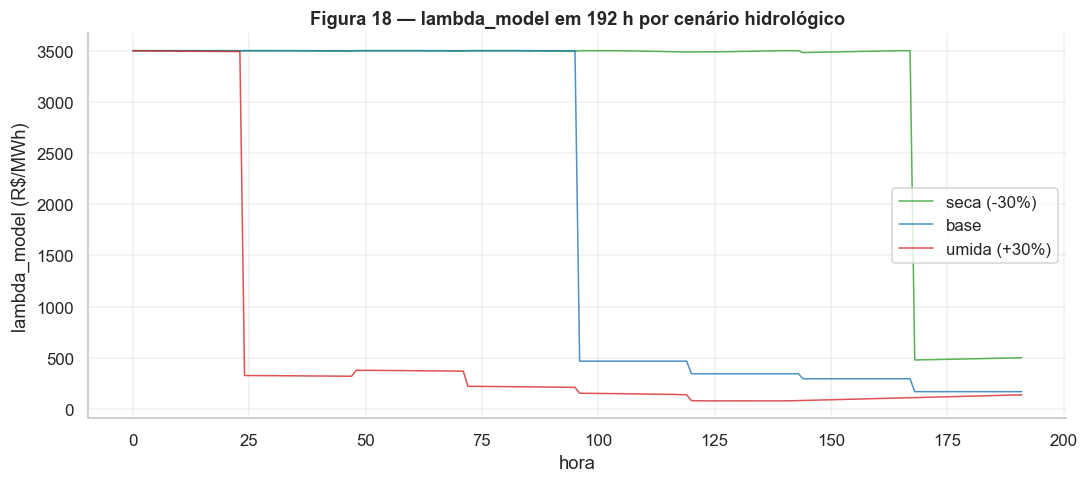

In [21]:
SCEN_H = {"seca (-30%)": 0.7, "base": 1.0, "umida (+30%)": 1.3}
hidro_res = {name: solve_situational(K_S_SIT, kappa=0.5, hyd_scale=sc)
             for name, sc in SCEN_H.items()}

rows = []
for name, r in hidro_res.items():
    rows.append({
        "cenario": name,
        "cost (R$ x10^6)":            r["cost"] / 1e6,
        "G_th_total (GWh)":            r["n"].sum() / 1e3,
        "G_h_used (GWh)":              r["h"].sum() / 1e3,
        "spill (GWh)":                 r["spill"].sum() / 1e3,
        "curt_solar_total (GWh)":      (r["curt_solar_1"].sum() + r["curt_solar_2"].sum())/1e3,
        "deficit (MWh)":               r["deficit"].sum(),
        "lambda_model_mean (R$/MWh)":  r["P_avg_lambda"],
    })
val_agua = pd.DataFrame(rows)
val_agua.to_csv(TABLE_DIR / "tab_valor_agua_cenarios.csv", index=False, float_format="%.3f")
print(val_agua.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
for (name, r), color in zip(hidro_res.items(), ["#2ca02c", "#1f77b4", "#d62728"]):
    ax.plot(r["lambda_model"], lw=1.0, alpha=.8, color=color, label=name)
ax.set_title("Figura 18 — lambda_model em 192 h por cenário hidrológico")
ax.set_xlabel("hora"); ax.set_ylabel("lambda_model (R$/MWh)")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig18_valor_agua.png", bbox_inches="tight")
plt.show()


## 17. Utilitário geográfico — polígonos esquemáticos dos subsistemas

Tentamos primeiro carregar um shapefile/geopackage em
`data/geospatial/brasil_subsistemas.geojson`; se ausente, caímos para polígonos
esquemáticos (mesma estrutura de chave por subsistema).


In [22]:
SUBSYS_CENTROIDS = {
    "N":  (-5.0,  -55.0),
    "NE": (-9.0,  -40.0),
    "SE": (-18.5, -47.0),
    "S":  (-28.0, -52.0),
}
SUBSYS_POLYGONS = {
    "N":  [(-74, -10), (-74,   5), (-50,  5), (-44, -2), (-44, -10)],
    "NE": [(-46, -18), (-46,  -2), (-34, -3), (-34, -17), (-40, -18)],
    "SE": [(-58, -25), (-58, -15), (-48, -10), (-44, -10), (-39, -20),
           (-40, -24), (-50, -25)],
    "S":  [(-58, -34), (-58, -25), (-50, -25), (-48, -29), (-50, -34)],
}

GEO_FILE = GEO_DIR / "brasil_subsistemas.geojson"
USE_GEOJSON = GEO_FILE.exists()
if USE_GEOJSON:
    try:
        gj = json.loads(GEO_FILE.read_text(encoding="utf-8"))
        SUBSYS_POLYGONS_GJ = {}
        for feat in gj.get("features", []):
            key = feat.get("properties", {}).get("id_subsistema")
            geom = feat.get("geometry", {})
            if key and geom.get("type") == "Polygon":
                SUBSYS_POLYGONS_GJ[key] = [(c[0], c[1]) for c in geom["coordinates"][0]]
        if set(SUBSYS_POLYGONS_GJ.keys()) >= set(SUBSYS_ORDER):
            SUBSYS_POLYGONS = SUBSYS_POLYGONS_GJ
            print(f"[geo] Usando shapefile/geojson: {GEO_FILE}")
        else:
            USE_GEOJSON = False
    except Exception as e:
        print(f"[geo] falha ao ler {GEO_FILE}: {e} -> usando esquemáticos")
        USE_GEOJSON = False
if not USE_GEOJSON:
    print("[geo] Usando polígonos esquemáticos (data/geospatial/brasil_subsistemas.geojson ausente)")


def plot_subsystem_map(ax, value_per_subsys: dict, *,
                       cmap_name: str = "YlOrRd", title: str = "",
                       label_fmt: str = ".1f", label_unit: str = "",
                       vmin: float | None = None, vmax: float | None = None) -> None:
    """Mapa esquemático do Brasil com cor por subsistema, valor anotado."""
    cmap = cm.get_cmap(cmap_name)
    vals = np.array([value_per_subsys.get(s, np.nan) for s in SUBSYS_ORDER])
    vmin = vmin if vmin is not None else np.nanmin(vals)
    vmax = vmax if vmax is not None else np.nanmax(vals)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    patches, colors = [], []
    for sub in SUBSYS_ORDER:
        poly = SUBSYS_POLYGONS[sub]
        patches.append(MplPolygon(poly, closed=True))
        v = value_per_subsys.get(sub, np.nan)
        colors.append(cmap(norm(v)) if np.isfinite(v) else (0.9, 0.9, 0.9, 1.0))
    ax.add_collection(PatchCollection(patches, facecolor=colors,
                                      edgecolor="black", linewidth=1.0, alpha=0.85))
    for sub in SUBSYS_ORDER:
        lat, lon = SUBSYS_CENTROIDS[sub]
        v = value_per_subsys.get(sub, np.nan)
        ax.plot(lon, lat, "ko", markersize=5)
        label = f"{sub}\n{v:{label_fmt}}{label_unit}" if np.isfinite(v) else f"{sub}\n—"
        ax.annotate(label, (lon, lat), xytext=(0, -15), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    ax.set_xlim(-76, -32); ax.set_ylim(-36, 8)
    ax.set_aspect("equal")
    ax.set_xlabel("longitude (°)"); ax.set_ylabel("latitude (°)")
    ax.set_title(title); ax.grid(alpha=.2)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=.6)


[geo] Usando polígonos esquemáticos (data/geospatial/brasil_subsistemas.geojson ausente)


## 18. **Mean Field Game locacional discreto**

Implementação formal mínima — todos os 7 elementos exigidos:

1. **Estado individual** `x = (ell, k_bin, theta_bin)`.
2. **Ação individual** `a ∈ {-Δk, 0, +Δk}` (capacidade); realocação tratada
   em iteração externa (best-response a melhor `ell`).
3. **Distribuição populacional** `m[ell, k_bin, theta_bin]` com `m.sum() == 1`.
4. **Problema de controle individual**: dado `lambda_loc[ell, t]`, cada
   tipo `(ell, k, theta)` maximiza
   `Rev_year − Inv_year − Adj_cost − Curtailment_risk_cost`.
5. **Atualização forward** `m_next[x_next] += m[x]` + difusão pequena.
6. **Fechamento de mercado**: clearing locacional → `lambda_new[ell, t]`.
7. **Iteração de ponto fixo** com relaxação em `lambda` e `m`.

Como a infra-estrutura computacional é compacta, mantemos o nome formal
**Mean Field Game locacional discreto**.


In [23]:
# Perfis horários típicos por subsistema (dia típico anual)
typ_loc = (panel.groupby(["id_subsistema", "hora"])
                .agg(L=("L_global", "mean"),
                     Gs=("G_s_total", "mean"),
                     Gw=("G_w_total", "mean"),
                     Gh=("G_h_total", "mean"),
                     Gth=("G_th_total", "mean"),
                     Gnuc=("G_nuc_inflex", "mean"),
                     CMO_obs=("CMO_obs", "mean"))
                .reset_index())

# Intercâmbio: limites por corredor
intc_raw = pd.read_csv(paths.interc_interno_path, sep=";", parse_dates=["din_instante"])
intc_raw = intc_raw[intc_raw["din_instante"].between(DATE_MIN, DATE_MAX)]
intc_raw["o"] = intc_raw["nom_subsistema_origem"].astype(str).map(canonical_subsys)
intc_raw["d"] = intc_raw["nom_subsistema_destino"].astype(str).map(canonical_subsys)
flow_lim = (intc_raw.groupby(["o", "d"])["val_intercambiomwmed"]
            .apply(lambda x: float(np.nanquantile(x.abs(), 0.99))).reset_index()
            .rename(columns={"val_intercambiomwmed": "F_max"}))

ALL_LINKS = [("N", "NE"), ("N", "SE"), ("NE", "SE"), ("SE", "S")]
F_MAX = {(o, d): float(flow_lim.query("o == @o and d == @d")["F_max"].iloc[0])
        if len(flow_lim.query("o == @o and d == @d")) else 0.0
        for (o, d) in ALL_LINKS}
print("F_max por corredor:", {k: f"{v:.0f}" for k, v in F_MAX.items()})

# Perfis por subsistema (24h)
HOURS = 24
def _arr(sub, col):
    s = (typ_loc.query("id_subsistema == @sub")
                 .set_index("hora")
                 .sort_index()[col]
                 .reindex(range(HOURS)))
    return s.ffill().bfill().fillna(0.0).values

L_lt    = {s: _arr(s, "L")  for s in SUBSYS_ORDER}
Gw_lt   = {s: _arr(s, "Gw") for s in SUBSYS_ORDER}
Gnuc_lt = {s: _arr(s, "Gnuc") for s in SUBSYS_ORDER}
Havail_lt = {s: _arr(s, "Gh") for s in SUBSYS_ORDER}
a_s_loc = {s: (_arr(s, "Gs") / max(K_eff.loc[s, "K_s_eff_p99"], 1e-6)).clip(0, 1.5)
           for s in SUBSYS_ORDER}
K_TH_loc  = {s: float(K_eff.loc[s, "K_th_eff_p99"]) for s in SUBSYS_ORDER}
K_H_loc   = {s: float(K_eff.loc[s, "K_h_eff_p99"])  for s in SUBSYS_ORDER}

# c1, c2 locais (apenas térmica)
c1_loc, c2_loc = {}, {}
for s in SUBSYS_ORDER:
    g = panel[(panel["id_subsistema"] == s)].dropna(subset=["CMO_obs"])
    if len(g) < 30:
        c1_loc[s], c2_loc[s] = c1_sit, c2_sit
        continue
    y = g["CMO_obs"].values
    x = g["G_th_total"].values
    A_lst = np.column_stack([np.ones_like(x), x])
    cf, *_ = np.linalg.lstsq(A_lst, y, rcond=None)
    c1_loc[s] = max(float(cf[0]), 50.0)
    c2_loc[s] = max(float(cf[1]), 5e-3)
print("c1_loc:", {s: f"{c1_loc[s]:.1f}" for s in SUBSYS_ORDER})


F_max por corredor: {('N', 'NE'): '5651', ('N', 'SE'): '9580', ('NE', 'SE'): '7629', ('SE', 'S'): '8576'}
c1_loc: {'N': '50.0', 'NE': '84.3', 'SE': '96.4', 'S': '141.1'}


In [24]:
def clearing_locacional(G_s_lt: dict, *,
                       water_opportunity_cost: float = 80.0,
                       pi_curt: float = 30.0, pi_def: float = 3500.0) -> dict:
    """Clearing locacional 24h. Recebe oferta solar agregada G_s_lt[ell] (vinda do MFG).

    Balanço por subsistema:
      G_s + Gw + Gnuc + h + n + (inflow - outflow) = L + curt - deficit

    Retorna lambda_loc[ell, t] = -bal.dual_value.
    """
    locs = SUBSYS_ORDER
    n = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    h = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    curt = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    defc = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    F = {(o, d): cp.Variable(HOURS) for (o, d) in ALL_LINKS}

    cost = 0
    for l in locs:
        cost += (c1_loc[l] * cp.sum(n[l]) + 0.5 * c2_loc[l] * cp.sum_squares(n[l])
                 + water_opportunity_cost * cp.sum(h[l])
                 + pi_def * cp.sum(defc[l]) + pi_curt * cp.sum(curt[l]))

    bal = {}
    cons = []
    for l in locs:
        inflow  = sum(F[(o, d)] for (o, d) in ALL_LINKS if d == l)
        outflow = sum(F[(o, d)] for (o, d) in ALL_LINKS if o == l)
        bal[l] = (G_s_lt[l] + Gw_lt[l] + Gnuc_lt[l] + h[l] + n[l] + inflow - outflow) \
                 == (L_lt[l] + curt[l] - defc[l])
        cons.append(bal[l])
        cons.append(n[l] <= K_TH_loc[l])
        cons.append(h[l] <= Havail_lt[l])
        cons.append(cp.sum(h[l]) <= Havail_lt[l].sum() * 0.95)
    for (o, d) in ALL_LINKS:
        cons.append(F[(o, d)] <=  F_MAX[(o, d)])
        cons.append(F[(o, d)] >= -F_MAX[(o, d)])

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)

    lam_l = {l: -bal[l].dual_value if bal[l].dual_value is not None else np.full(HOURS, np.nan)
             for l in locs}
    return {
        "status": prob.status, "cost": float(prob.value),
        "n":    {l: n[l].value    for l in locs},
        "h":    {l: h[l].value    for l in locs},
        "curt": {l: curt[l].value for l in locs},
        "deficit": {l: defc[l].value for l in locs},
        "F":    {k: F[k].value    for k in F},
        "lambda_loc": lam_l,
    }


### 18.1 MFG — espaço de estados, ações, custos e dinâmica

- Locações: 4 subsistemas.
- `k_bin ∈ {0, 1, ..., K_BINS_N - 1}`; cada bin vale `cap_unit` MW.
- `theta_bin ∈ {0, 1, 2}` (baixo/médio/alto), produtividade `prod[theta]`.
- Ações: `a ∈ {-Δk, 0, +Δk}` (em unidades de bin).
- Distribuição `m[ell, k, theta]` com `m.sum() == 1`.
- `N_AGENTS` é apenas escala — capacidade real é `N_AGENTS · cap_unit · k_value`.
- `cap_unit` calibrado para que a capacidade agregada inicial bata com `K_S_obs`.


In [25]:
# Grade discreta
LOCS = SUBSYS_ORDER
N_LOC = len(LOCS)
K_BINS = np.arange(0, 9)        # 0..8 unidades de capacidade
N_K = len(K_BINS)
THETA_BINS = np.array([0, 1, 2])  # baixo, médio, alto
PROD = {0: 0.90, 1: 1.00, 2: 1.10}
N_THETA = len(THETA_BINS)
ACTIONS = np.array([-1, 0, +1])  # delta_k

# Calibração: total de capacidade observada
K_S_OBS_TOTAL = float(K_eff.loc[:, "K_s_eff_p99"].sum())
N_AGENTS = 100.0     # mass total (escala)
# Inicial: agentes uniformes em k=4, theta=1, distribuídos por ell proporcional a K_s_obs[ell]
m0 = np.zeros((N_LOC, N_K, N_THETA))
for i, ell in enumerate(LOCS):
    share = K_eff.loc[ell, "K_s_eff_p99"] / K_S_OBS_TOTAL
    m0[i, 4, 1] = share
assert abs(m0.sum() - 1.0) < 1e-9

# cap_unit calibrado para que aggregated capacity inicial == K_S_OBS_TOTAL:
# K_agg = N_AGENTS * cap_unit * E[k_bin]  ;  com m0 toda em k=4 => E[k] = 4
cap_unit = K_S_OBS_TOTAL / (N_AGENTS * 4.0)
print(f"cap_unit = {cap_unit:.1f} MW por unidade de bin (N_AGENTS={N_AGENTS:.0f})")

# Custos regionais (R$/MW/ano) — anualização CAPEX 25y WACC 8%
WACC = 0.08; VIDA = 25
FATOR_ANUAL = WACC * (1 + WACC)**VIDA / ((1 + WACC)**VIDA - 1)
capex_reg = {"N": 4.2, "NE": 3.6, "SE": 3.8, "S": 4.0}     # MR$/MW
conn_reg  = {"N": 0.40, "NE": 0.30, "SE": 0.15, "S": 0.22}
om_reg    = {"N": 0.084, "NE": 0.072, "SE": 0.076, "S": 0.080}
q_reg = {s: (capex_reg[s] + conn_reg[s]) * 1e6 * FATOR_ANUAL + om_reg[s] * 1e6
         for s in SUBSYS_ORDER}
print("q_reg (R$/MW/ano):", {s: f"{q_reg[s]:,.0f}" for s in SUBSYS_ORDER})

# Custo de ajuste (chi) por (k_next - k)^2 em MW^2
CHI_ADJ = 0.05      # R$/MW^2/ano (suavização)

# Difusão regularizadora
EPS_DIFF = 0.01

def agg_solar_from_m(m: np.ndarray) -> dict:
    """G_s[ell, t] = N_AGENTS * cap_unit * sum_{k,theta} m[ell,k,theta] * k * prod[theta] * a_s_loc[ell,t]."""
    G = {}
    for i, ell in enumerate(LOCS):
        cap_w = float(sum(
            m[i, kb, tb] * K_BINS[kb] * PROD[THETA_BINS[tb]]
            for kb in range(N_K) for tb in range(N_THETA)
        ))
        cap_MW = N_AGENTS * cap_unit * cap_w
        G[ell] = cap_MW * a_s_loc[ell]
    return G


def annual_revenue_per_MW(lam_loc_h: np.ndarray, ell: str) -> float:
    """Receita anual por MW instalado em ell, dada lambda_loc[ell,t] de 1 dia típico."""
    # 24h típica * 365 dias
    return float((lam_loc_h * a_s_loc[ell]).sum()) * 365.0


def best_response_capacity(m: np.ndarray, lam_loc: dict) -> tuple[np.ndarray, np.ndarray]:
    """Para cada estado x=(ell,k,theta), escolhe a* ∈ {-1, 0, +1}.

    Retorna policy[i, kb, tb] -> índice em ACTIONS e profit[i, kb, tb] (valor).
    """
    policy = np.zeros((N_LOC, N_K, N_THETA), dtype=int)
    profit = np.full((N_LOC, N_K, N_THETA), -np.inf)
    for i, ell in enumerate(LOCS):
        rev_per_MW = annual_revenue_per_MW(lam_loc[ell], ell)
        q_ell = q_reg[ell]
        for kb in range(N_K):
            for tb in range(N_THETA):
                theta_v = THETA_BINS[tb]
                prod = PROD[theta_v]
                best_p = -np.inf; best_a = 0
                for ai, a in enumerate(ACTIONS):
                    kb_next = int(np.clip(kb + a, 0, N_K - 1))
                    k_next = K_BINS[kb_next]
                    # capacidade instalada por agente (MW) após ação
                    cap_MW = cap_unit * k_next * prod
                    # rev anual (R$) por agente
                    rev = rev_per_MW * cap_MW
                    inv = q_ell * cap_MW
                    adj = CHI_ADJ * (cap_unit * (K_BINS[kb_next] - K_BINS[kb]))**2
                    p = rev - inv - adj
                    if p > best_p:
                        best_p = p; best_a = ai
                policy[i, kb, tb] = best_a
                profit[i, kb, tb] = best_p
    return policy, profit


def forward_update(m: np.ndarray, policy: np.ndarray,
                   eps: float = EPS_DIFF) -> np.ndarray:
    """m_new[x_next] += m[x] sob política; aplica difusão eps."""
    m_new = np.zeros_like(m)
    for i in range(N_LOC):
        for kb in range(N_K):
            for tb in range(N_THETA):
                a = ACTIONS[policy[i, kb, tb]]
                kb_next = int(np.clip(kb + a, 0, N_K - 1))
                m_new[i, kb_next, tb] += m[i, kb, tb]
    # difusão pequena
    m_uniform = np.full_like(m_new, 1.0 / m_new.size)
    m_new = (1 - eps) * m_new + eps * m_uniform
    m_new /= m_new.sum()
    return m_new


def relocate_step(m: np.ndarray, lam_loc: dict,
                  rate: float = 0.05) -> np.ndarray:
    """Move uma fração `rate` da massa de cada (ell,k,theta) para o ell* mais
    rentável (sem custo adicional além de adjustment já contabilizado)."""
    # rev por MW por ell
    rev_per_MW = {ell: annual_revenue_per_MW(lam_loc[ell], ell) - q_reg[ell]
                  for ell in LOCS}
    best_ell = max(rev_per_MW, key=rev_per_MW.get)
    j_best = LOCS.index(best_ell)
    m_out = m.copy()
    moved = 0.0
    for i in range(N_LOC):
        if i == j_best:
            continue
        for kb in range(N_K):
            for tb in range(N_THETA):
                delta = rate * m_out[i, kb, tb]
                m_out[i, kb, tb] -= delta
                m_out[j_best, kb, tb] += delta
                moved += delta
    return m_out


cap_unit = 33.7 MW por unidade de bin (N_AGENTS=100)
q_reg (R$/MW/ano): {'N': '514,922', 'NE': '437,347', 'SE': '446,031', 'S': '475,324'}


### 18.2 Iteração de ponto fixo MFG

In [26]:
MAX_ITER = 25
OMEGA_LAM = 0.5
OMEGA_M   = 0.5
TOL = 5e-3
RELOC_RATE = 0.04

# Inicialização: lambda do clearing com m0
G_s_init = agg_solar_from_m(m0)
res0 = clearing_locacional(G_s_init,
                           water_opportunity_cost=PARAMS["water_opportunity_cost"],
                           pi_curt=PARAMS["pi_curt_RS_per_MWh"],
                           pi_def=PARAMS["pi_def_RS_per_MWh"])
lam_loc = {ell: res0["lambda_loc"][ell].copy() for ell in LOCS}
m = m0.copy()

mfg_history = {
    "iteration": [],
    "err_lambda": [],
    "err_m": [],
    "total_capacity_MW": [],
    "total_curtailment_MWh": [],
    "avg_lambda": [],
}

for it in range(1, MAX_ITER + 1):
    # 1) Best response (capacidade)
    policy, profit = best_response_capacity(m, lam_loc)
    # 2) Forward
    m_new = forward_update(m, policy, eps=EPS_DIFF)
    # 3) Relocação leve
    m_new = relocate_step(m_new, lam_loc, rate=RELOC_RATE)
    # 4) Clearing com novo m
    G_s_new = agg_solar_from_m(m_new)
    res_new = clearing_locacional(G_s_new,
                                  water_opportunity_cost=PARAMS["water_opportunity_cost"],
                                  pi_curt=PARAMS["pi_curt_RS_per_MWh"],
                                  pi_def=PARAMS["pi_def_RS_per_MWh"])
    lam_new = {ell: res_new["lambda_loc"][ell] for ell in LOCS}
    # 5) Erros
    err_lambda = max(float(np.nanmax(np.abs(lam_new[ell] - lam_loc[ell]))) for ell in LOCS)
    err_m = float(np.nanmax(np.abs(m_new - m)))
    # 6) Relaxação
    lam_loc = {ell: (1 - OMEGA_LAM) * lam_loc[ell] + OMEGA_LAM * lam_new[ell] for ell in LOCS}
    m = (1 - OMEGA_M) * m + OMEGA_M * m_new
    m /= m.sum()

    cap_total = float(sum(
        N_AGENTS * cap_unit * m[i, kb, tb] * K_BINS[kb] * PROD[THETA_BINS[tb]]
        for i in range(N_LOC) for kb in range(N_K) for tb in range(N_THETA)
    ))
    curt_total = float(sum(res_new["curt"][ell].sum() for ell in LOCS))
    avg_lam = float(np.mean([lam_loc[ell].mean() for ell in LOCS]))
    mfg_history["iteration"].append(it)
    mfg_history["err_lambda"].append(err_lambda)
    mfg_history["err_m"].append(err_m)
    mfg_history["total_capacity_MW"].append(cap_total)
    mfg_history["total_curtailment_MWh"].append(curt_total)
    mfg_history["avg_lambda"].append(avg_lam)
    print(f"iter={it:>2} | err_lam={err_lambda:>8.3f} err_m={err_m:>7.4f} "
          f"K_tot={cap_total/1000:.1f}GW λ̄={avg_lam:.1f}")
    if max(err_lambda, err_m) < TOL:
        print(f"Convergência atingida em {it} iterações.")
        break

mfg_hist_df = pd.DataFrame(mfg_history)
mfg_hist_df.to_csv(TABLE_DIR / "tab_mfg_history.csv", index=False, float_format="%.4f")
res_mfg = res_new
m_mfg = m.copy()
lam_mfg = lam_loc.copy()


iter= 1 | err_lam=   0.914 err_m= 0.5314 K_tot=15.1GW λ̄=1608.5
iter= 2 | err_lam=   0.901 err_m= 0.2657 K_tot=16.8GW λ̄=1608.3
iter= 3 | err_lam=2978.008 err_m= 0.1328 K_tot=18.4GW λ̄=1546.0
iter= 4 | err_lam=1584.340 err_m= 0.1262 K_tot=20.1GW λ̄=1512.7


iter= 5 | err_lam=2966.817 err_m= 0.1073 K_tot=21.6GW λ̄=1432.5
iter= 6 | err_lam=1563.269 err_m= 0.1318 K_tot=22.9GW λ̄=1389.4
iter= 7 | err_lam= 841.124 err_m= 0.1286 K_tot=24.0GW λ̄=1366.5


iter= 8 | err_lam= 463.083 err_m= 0.1085 K_tot=24.8GW λ̄=1354.0
iter= 9 | err_lam= 261.342 err_m= 0.0821 K_tot=25.4GW λ̄=1347.1
iter=10 | err_lam= 151.567 err_m= 0.0564 K_tot=25.8GW λ̄=1343.2


iter=11 | err_lam=  86.440 err_m= 0.0411 K_tot=26.0GW λ̄=1341.0
iter=12 | err_lam=  44.834 err_m= 0.0370 K_tot=26.2GW λ̄=1339.9
iter=13 | err_lam=  23.680 err_m= 0.0337 K_tot=26.3GW λ̄=1339.3
iter=14 | err_lam=  12.884 err_m= 0.0311 K_tot=26.4GW λ̄=1339.0


iter=15 | err_lam=   7.335 err_m= 0.0291 K_tot=26.4GW λ̄=1338.8
iter=16 | err_lam=   4.331 err_m= 0.0275 K_tot=26.5GW λ̄=1338.8
iter=17 | err_lam=   2.750 err_m= 0.0262 K_tot=26.5GW λ̄=1338.7


iter=18 | err_lam=   2.415 err_m= 0.0251 K_tot=26.5GW λ̄=1338.7
iter=19 | err_lam=   2.565 err_m= 0.0242 K_tot=26.5GW λ̄=1338.7
iter=20 | err_lam=   2.620 err_m= 0.0234 K_tot=26.5GW λ̄=1338.8


iter=21 | err_lam=   8.989 err_m= 0.0226 K_tot=26.5GW λ̄=1338.9
iter=22 | err_lam=  13.243 err_m= 0.0219 K_tot=26.5GW λ̄=1339.1
iter=23 | err_lam=  15.160 err_m= 0.0212 K_tot=26.5GW λ̄=1339.4
iter=24 | err_lam=  15.908 err_m= 0.0206 K_tot=26.5GW λ̄=1339.7
iter=25 | err_lam=  16.077 err_m= 0.0199 K_tot=26.5GW λ̄=1340.0


### 18.3 Outputs do MFG — tabelas e figuras

In [27]:
# Capacidade agregada por subsistema no equilíbrio MFG
K_by_subsys_mfg = {}
for i, ell in enumerate(LOCS):
    cap = sum(N_AGENTS * cap_unit * m_mfg[i, kb, tb] * K_BINS[kb] * PROD[THETA_BINS[tb]]
              for kb in range(N_K) for tb in range(N_THETA))
    K_by_subsys_mfg[ell] = float(cap)

# Receita capturada por subsistema (sob lambda_loc final)
R_cap_mfg = {}
for ell in LOCS:
    lam = lam_mfg[ell]
    g_solar = K_by_subsys_mfg[ell] * a_s_loc[ell]
    R_cap_mfg[ell] = float((lam * g_solar).sum() / max(g_solar.sum(), 1e-9))

# Tabela summary
summary_rows = []
for ell in LOCS:
    summary_rows.append({
        "subsistema": ell,
        "K_obs_MW":      float(K_eff.loc[ell, "K_s_eff_p99"]),
        "K_mfg_MW":      K_by_subsys_mfg[ell],
        "delta_K_pct":   100.0 * (K_by_subsys_mfg[ell] / max(K_eff.loc[ell, "K_s_eff_p99"], 1e-6) - 1),
        "lambda_loc_mean": float(lam_mfg[ell].mean()),
        "R_cap_mfg":     R_cap_mfg[ell],
        "curt_mfg_MWh":  float(res_mfg["curt"][ell].sum()),
        "deficit_mfg_MWh": float(res_mfg["deficit"][ell].sum()),
    })
mfg_summary = pd.DataFrame(summary_rows)
mfg_summary.to_csv(TABLE_DIR / "tab_mfg_equilibrium_summary.csv", index=False, float_format="%.3f")
print("Equilíbrio MFG por subsistema:")
print(mfg_summary.round(2).to_string(index=False))

# Distribuição por localização (marginalizada em k, theta)
dist_rows = []
for i, ell in enumerate(LOCS):
    for kb in range(N_K):
        for tb in range(N_THETA):
            dist_rows.append({
                "subsistema": ell, "k_bin": int(K_BINS[kb]),
                "theta_bin": int(THETA_BINS[tb]),
                "m": float(m_mfg[i, kb, tb]),
                "cap_MW": float(N_AGENTS * cap_unit * m_mfg[i, kb, tb] * K_BINS[kb] * PROD[THETA_BINS[tb]]),
            })
dist_df = pd.DataFrame(dist_rows)
dist_df.to_csv(TABLE_DIR / "tab_mfg_distribution_by_location.csv", index=False, float_format="%.6f")
print(f"\nDistribuição salva: {len(dist_df)} linhas.")


Equilíbrio MFG por subsistema:
subsistema  K_obs_MW  K_mfg_MW  delta_K_pct  lambda_loc_mean  R_cap_mfg  curt_mfg_MWh  deficit_mfg_MWh
         N      4.00  10597.15    264828.83          1340.04    3061.31           0.0         10033.42
        NE   7159.31   8151.38        13.86          1340.04    2897.16           0.0         13096.95
        SE   6304.59   7238.96        14.82          1340.04    2894.40           0.0         52189.27
         S      2.00    511.00     25450.19          1340.04    1428.42           0.0         50448.90

Distribuição salva: 108 linhas.


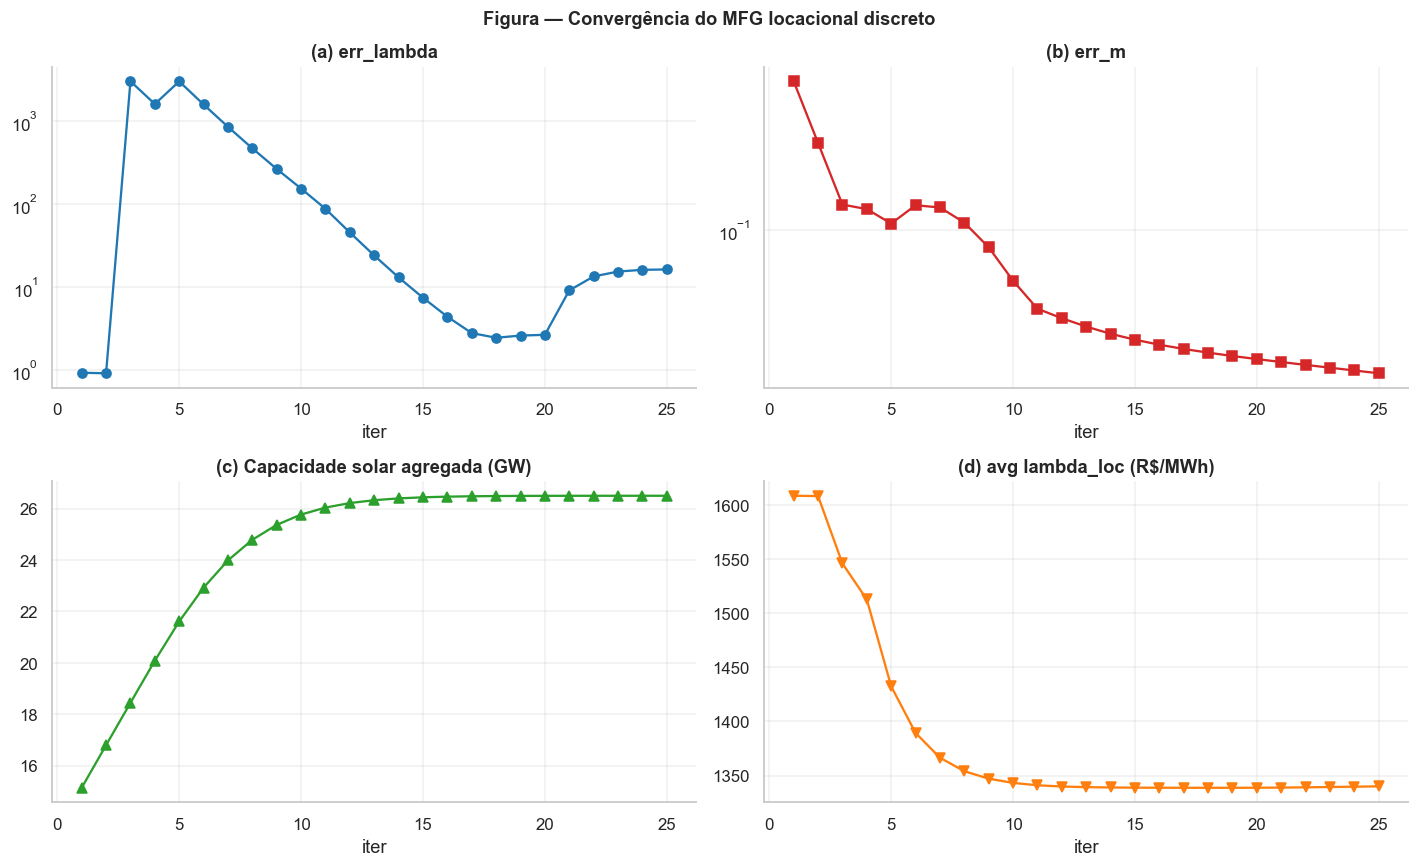

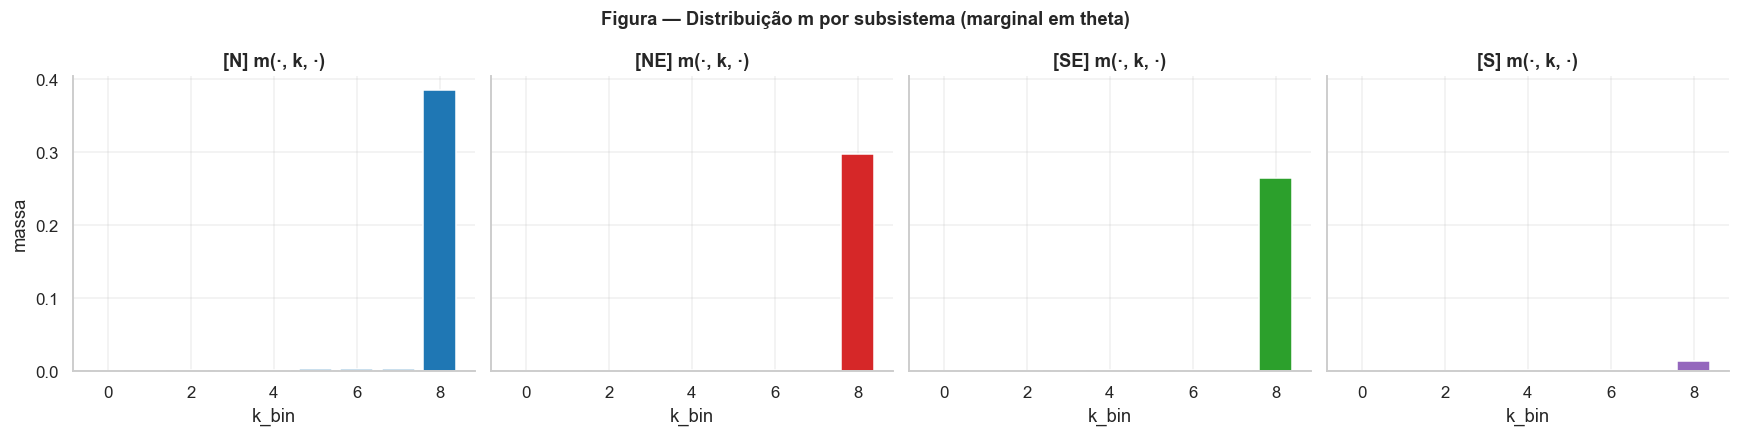

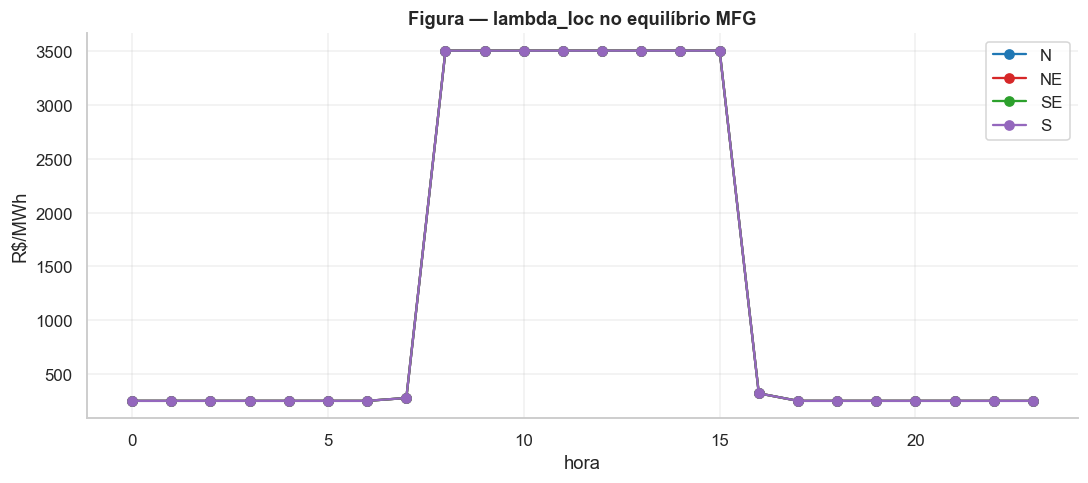

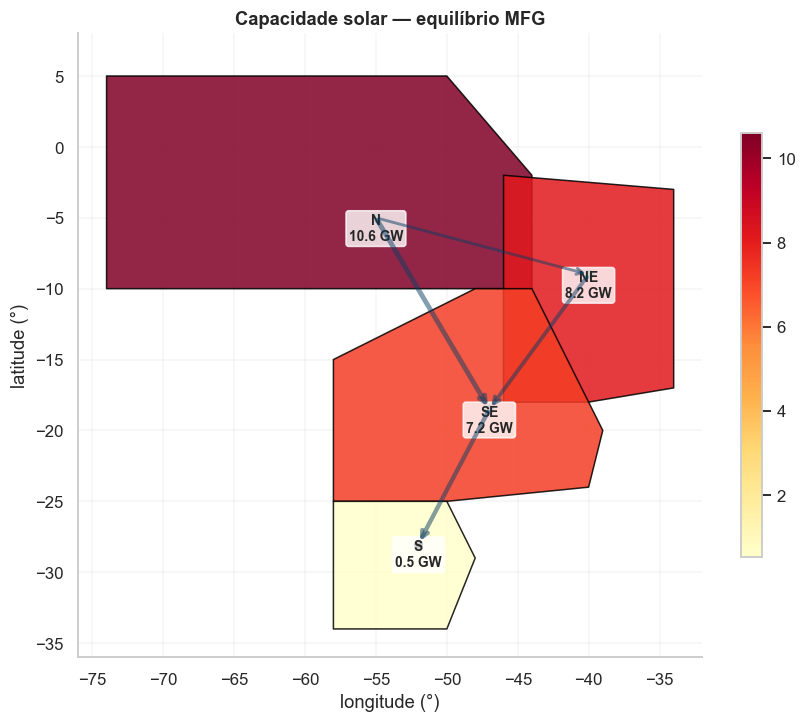

In [28]:
# Figura: convergência
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(mfg_history["iteration"], mfg_history["err_lambda"], "o-", color="#1f77b4")
axes[0, 0].set_yscale("log"); axes[0, 0].set_title("(a) err_lambda")
axes[0, 0].set_xlabel("iter"); axes[0, 0].grid(alpha=.3)
axes[0, 1].plot(mfg_history["iteration"], mfg_history["err_m"], "s-", color="#d62728")
axes[0, 1].set_yscale("log"); axes[0, 1].set_title("(b) err_m")
axes[0, 1].set_xlabel("iter"); axes[0, 1].grid(alpha=.3)
axes[1, 0].plot(mfg_history["iteration"], np.array(mfg_history["total_capacity_MW"])/1000, "^-", color="#2ca02c")
axes[1, 0].set_title("(c) Capacidade solar agregada (GW)")
axes[1, 0].set_xlabel("iter"); axes[1, 0].grid(alpha=.3)
axes[1, 1].plot(mfg_history["iteration"], mfg_history["avg_lambda"], "v-", color="#ff7f0e")
axes[1, 1].set_title("(d) avg lambda_loc (R$/MWh)")
axes[1, 1].set_xlabel("iter"); axes[1, 1].grid(alpha=.3)
fig.suptitle("Figura — Convergência do MFG locacional discreto",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_mfg_convergence.png", bbox_inches="tight")
plt.show()

# Figura: distribuição m por localização (marginal em k)
fig, axes = plt.subplots(1, N_LOC, figsize=(16, 4), sharey=True)
for i, ell in enumerate(LOCS):
    ax = axes[i]
    M_k = m_mfg[i].sum(axis=1)   # marginal sobre theta
    ax.bar(K_BINS, M_k, color=SUB_COLOR[ell])
    ax.set_title(f"[{ell}] m(·, k, ·)")
    ax.set_xlabel("k_bin"); ax.grid(alpha=.3)
axes[0].set_ylabel("massa")
fig.suptitle("Figura — Distribuição m por subsistema (marginal em theta)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_mfg_distribution_by_location.png", bbox_inches="tight")
plt.show()

# Figura: lambda_loc por subsistema
fig, ax = plt.subplots(figsize=(10, 4.5))
for ell in LOCS:
    ax.plot(np.arange(HOURS), lam_mfg[ell], "o-", color=SUB_COLOR[ell], label=ell)
ax.set_title("Figura — lambda_loc no equilíbrio MFG")
ax.set_xlabel("hora"); ax.set_ylabel("R$/MWh"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_mfg_prices_by_location.png", bbox_inches="tight")
plt.show()

# Mapa: capacidade MFG por subsistema
fig, ax = plt.subplots(figsize=(8, 7))
plot_subsystem_map(ax, {ell: K_by_subsys_mfg[ell]/1000 for ell in LOCS},
                   cmap_name="YlOrRd", title="Capacidade solar — equilíbrio MFG",
                   label_fmt=".1f", label_unit=" GW")
for (o, d) in ALL_LINKS:
    la_o, lo_o = SUBSYS_CENTROIDS[o]
    la_d, lo_d = SUBSYS_CENTROIDS[d]
    ax.annotate("", xy=(lo_d, la_d), xytext=(lo_o, la_o),
                arrowprops=dict(arrowstyle="->", color="#0a3d62",
                                lw=max(1, F_MAX[(o, d)]/3000), alpha=0.5))
fig.tight_layout()
fig.savefig(FIG_DIR / "map_mfg_capacity_by_subsystem.png", bbox_inches="tight")
plt.show()


## 19. Investimento: alocação com orçamento fixo × livre entrada

Diferenciamos duas modalidades:

1. **`allocation_fixed_budget`**: capacidade total `K_TOT` é fixa; resolvemos a
   alocação `K_alloc[ell]` que minimiza o custo social agregado.
2. **`allocation_free_entry`**: para cada `K` na grade, calculamos margem
   privada por MW. Se margem ≥ 0, entra; senão, não entra. **Não** chamamos de
   equilíbrio se a margem permanece positiva no topo da grade (ampliar grid).


Alocação fixed-budget:
  K_N =   4.03 GW (obs   0.00 GW)
  K_NE =   3.74 GW (obs   7.16 GW)
  K_SE =   3.68 GW (obs   6.30 GW)
  K_S =   2.02 GW (obs   0.00 GW)

Varredura free-entry:
 K_total_MW  K_total_GW      cost_op    inv_anual    rev_anual  margem_anual  total_social entry_decision
     4041.0         4.0 1091742719.0 1.783848e+09 3.192419e+10  3.014034e+10  2.875590e+09             in
     6735.0         7.0 1033435089.0 2.973079e+09 5.320445e+10  5.023137e+10  4.006514e+09             in
     9429.0         9.0  975130234.0 4.162311e+09 7.448268e+10  7.032037e+10  5.137441e+09             in
    13470.0        13.0  887677455.0 5.946159e+09 1.063995e+11  1.004533e+11  6.833836e+09             in
    17511.0        18.0  800226479.0 7.730006e+09 1.383173e+11  1.305873e+11  8.530233e+09             in
    21552.0        22.0  716283852.0 9.513854e+09 1.586349e+11  1.491210e+11  1.023014e+10             in
    26940.0        27.0  612528923.0 1.189232e+10 1.836015e+11  1.717092e+

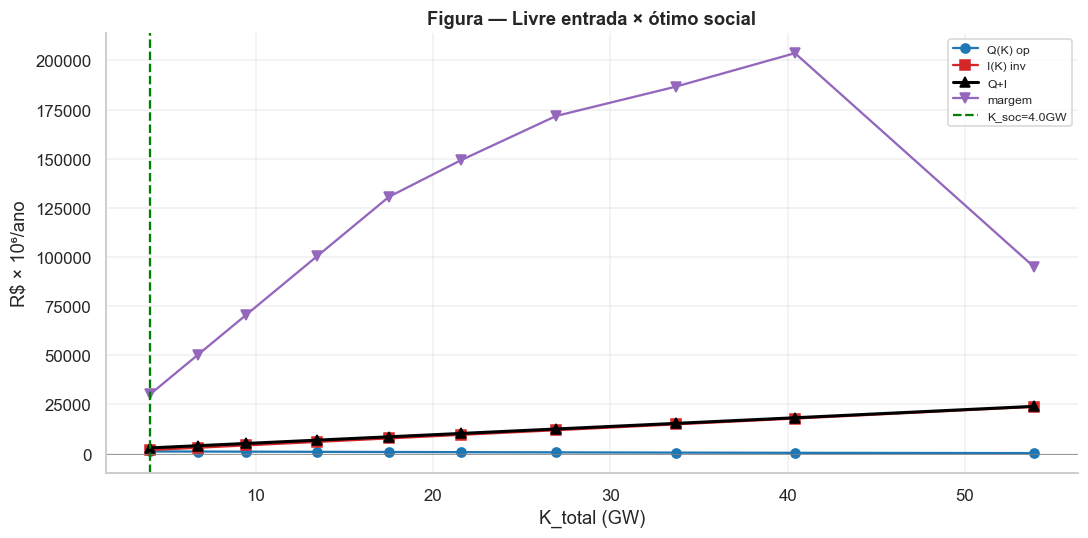

In [29]:
K_TOT = float(K_eff.loc[:, "K_s_eff_p99"].sum())

def allocation_fixed_budget(K_total: float, n_iter: int = 10, eta: float = 0.3) -> dict:
    """Alocação K_alloc[ell] que minimiza custo via best-response amortizado."""
    K_obs = {s: float(K_eff.loc[s, "K_s_eff_p99"]) for s in SUBSYS_ORDER}
    scale = K_total / sum(K_obs.values())
    K = {s: K_obs[s] * scale for s in SUBSYS_ORDER}
    hist = []
    for it in range(n_iter):
        G_s_alloc = {s: K[s] * a_s_loc[s] for s in SUBSYS_ORDER}
        r = clearing_locacional(G_s_alloc,
                                water_opportunity_cost=PARAMS["water_opportunity_cost"])
        rev = {}
        for s in SUBSYS_ORDER:
            rev[s] = float((r["lambda_loc"][s] * a_s_loc[s]).sum()) * 365.0
        marg = {s: rev[s] - q_reg[s] for s in SUBSYS_ORDER}
        pos = {s: max(marg[s], 0.0) for s in SUBSYS_ORDER}
        if sum(pos.values()) > 0:
            w = {s: pos[s] / sum(pos.values()) for s in SUBSYS_ORDER}
        else:
            w = {s: rev[s] / max(sum(rev.values()), 1e-9) for s in SUBSYS_ORDER}
        K_new = {s: (1 - eta) * K[s] + eta * w[s] * K_total for s in SUBSYS_ORDER}
        hist.append({"iter": it, **{f"K_{s}": K_new[s] for s in SUBSYS_ORDER},
                     **{f"marg_{s}": marg[s] for s in SUBSYS_ORDER}})
        K = K_new
    return {"K_alloc": K, "history": hist}


fixed_res = allocation_fixed_budget(K_TOT)
K_eq = fixed_res["K_alloc"]
print("Alocação fixed-budget:")
for s in SUBSYS_ORDER:
    print(f"  K_{s} = {K_eq[s]/1000:>6.2f} GW (obs {K_eff.loc[s,'K_s_eff_p99']/1000:>6.2f} GW)")


def allocation_free_entry(K_grid_MW: np.ndarray) -> pd.DataFrame:
    """Varre K_total e diagnostica entrada livre."""
    rows = []
    for K in K_grid_MW:
        K_alloc = {s: K * (K_eff.loc[s, "K_s_eff_p99"] / K_TOT) for s in SUBSYS_ORDER}
        G_s_alloc = {s: K_alloc[s] * a_s_loc[s] for s in SUBSYS_ORDER}
        r = clearing_locacional(G_s_alloc,
                                water_opportunity_cost=PARAMS["water_opportunity_cost"])
        rev_anual = 0.0
        inv_anual = 0.0
        for s in SUBSYS_ORDER:
            rev_anual += float((r["lambda_loc"][s] * a_s_loc[s] * K_alloc[s]).sum()) * 365.0
            inv_anual += q_reg[s] * K_alloc[s]
        rows.append({
            "K_total_MW": K,
            "K_total_GW": K/1000,
            "cost_op": r["cost"],
            "inv_anual": inv_anual,
            "rev_anual": rev_anual,
            "margem_anual": rev_anual - inv_anual,
            "total_social": r["cost"] + inv_anual,
            "entry_decision": "in" if (rev_anual - inv_anual) >= 0 else "out",
        })
    return pd.DataFrame(rows)


K_grid_MW = K_TOT * np.array([0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0, 2.5, 3.0, 4.0])
free_res = allocation_free_entry(K_grid_MW)
free_res.to_csv(TABLE_DIR / "tab_investimento_K_grid.csv", index=False, float_format="%.4f")
print("\nVarredura free-entry:")
print(free_res.round(0).to_string(index=False))

K_soc = float(free_res.loc[free_res["total_social"].idxmin(), "K_total_GW"])

mask_in = free_res["entry_decision"] == "in"
mask_out = free_res["entry_decision"] == "out"
if mask_in.all():
    K_priv = None
    diag_msg = (f"AVISO: margem >= 0 em TODA a grade (K_max = {free_res['K_total_GW'].max():.1f} GW). "
                "Não foi encontrado cruzamento na grade; ampliar grid ou regularizar o modelo.")
elif mask_out.all():
    K_priv = 0.0
    diag_msg = "Margem < 0 em TODA a grade => livre entrada implica K_priv = 0."
else:
    K_priv = float(free_res.loc[mask_in, "K_total_GW"].max())
    diag_msg = f"K_priv (maior K com margem >= 0) = {K_priv:.1f} GW."
print(f"\nK_soc = {K_soc:.1f} GW")
print(diag_msg)

# Tabela final: private vs social
priv_vs_soc = pd.DataFrame({
    "regime": ["allocation_fixed_budget", "allocation_free_entry", "social_optimum", "observed"],
    "K_total_GW": [K_TOT/1000, (K_priv if K_priv is not None else np.nan),
                   K_soc, K_S_OBS_TOTAL/1000],
    "comment": ["K fixo em K_TOT, distribuído por margem",
                diag_msg, "argmin Q+I na grade",
                "p99 da geração observada"],
})
priv_vs_soc.to_csv(TABLE_DIR / "tab_private_vs_social_capacity.csv",
                   index=False, float_format="%.3f")
print("\n", priv_vs_soc.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(free_res["K_total_GW"], free_res["cost_op"]/1e6,    "o-", color="#1f77b4", label="Q(K) op")
ax.plot(free_res["K_total_GW"], free_res["inv_anual"]/1e6,  "s-", color="#d62728", label="I(K) inv")
ax.plot(free_res["K_total_GW"], free_res["total_social"]/1e6,"^-", color="black", lw=2, label="Q+I")
ax.plot(free_res["K_total_GW"], free_res["margem_anual"]/1e6,"v-", color="#9467bd", label="margem")
ax.axhline(0, color="gray", ls="-", lw=.5)
ax.axvline(K_soc, color="green", ls="--", label=f"K_soc={K_soc:.1f}GW")
if K_priv is not None and K_priv > 0:
    ax.axvline(K_priv, color="orange", ls=":", label=f"K_priv={K_priv:.1f}GW")
ax.set_xlabel("K_total (GW)"); ax.set_ylabel("R$ × 10⁶/ano")
ax.set_title("Figura — Livre entrada × ótimo social")
ax.legend(fontsize=8); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_private_vs_social_capacity.png", bbox_inches="tight")
plt.show()


## 20. Mapas estáticos por subsistema

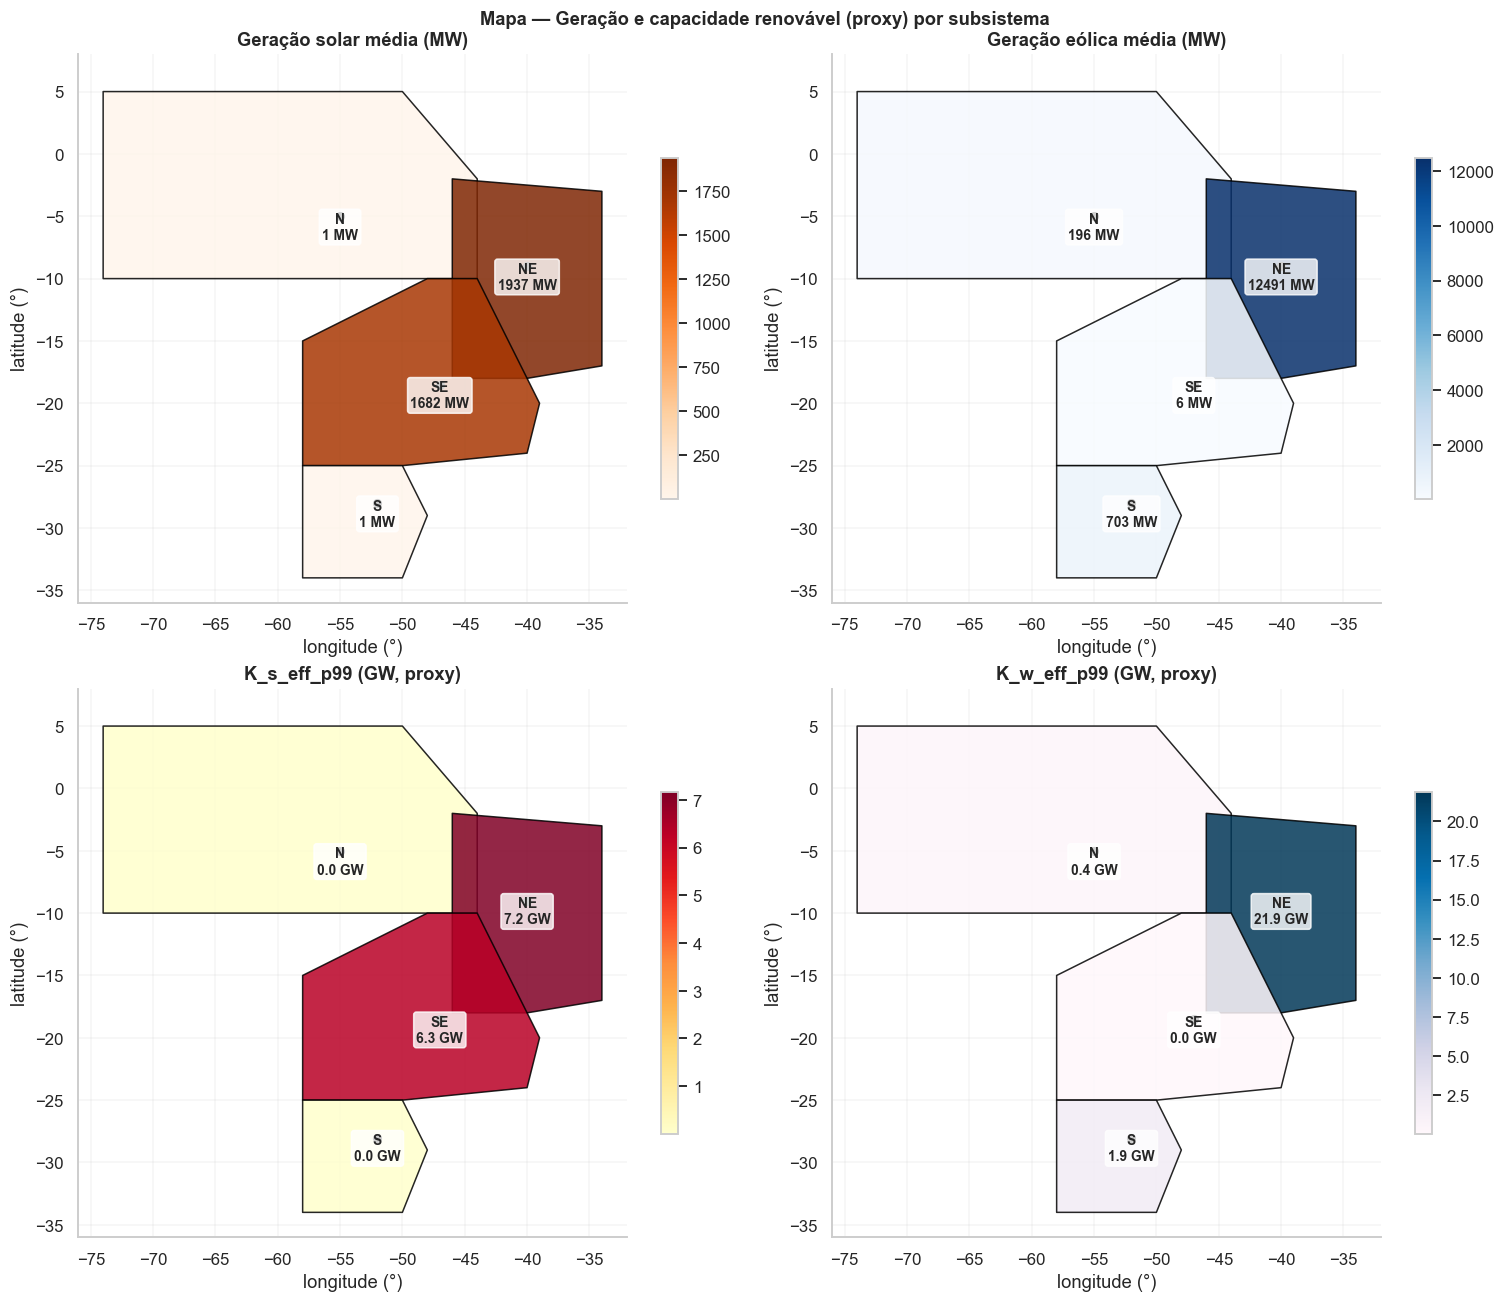

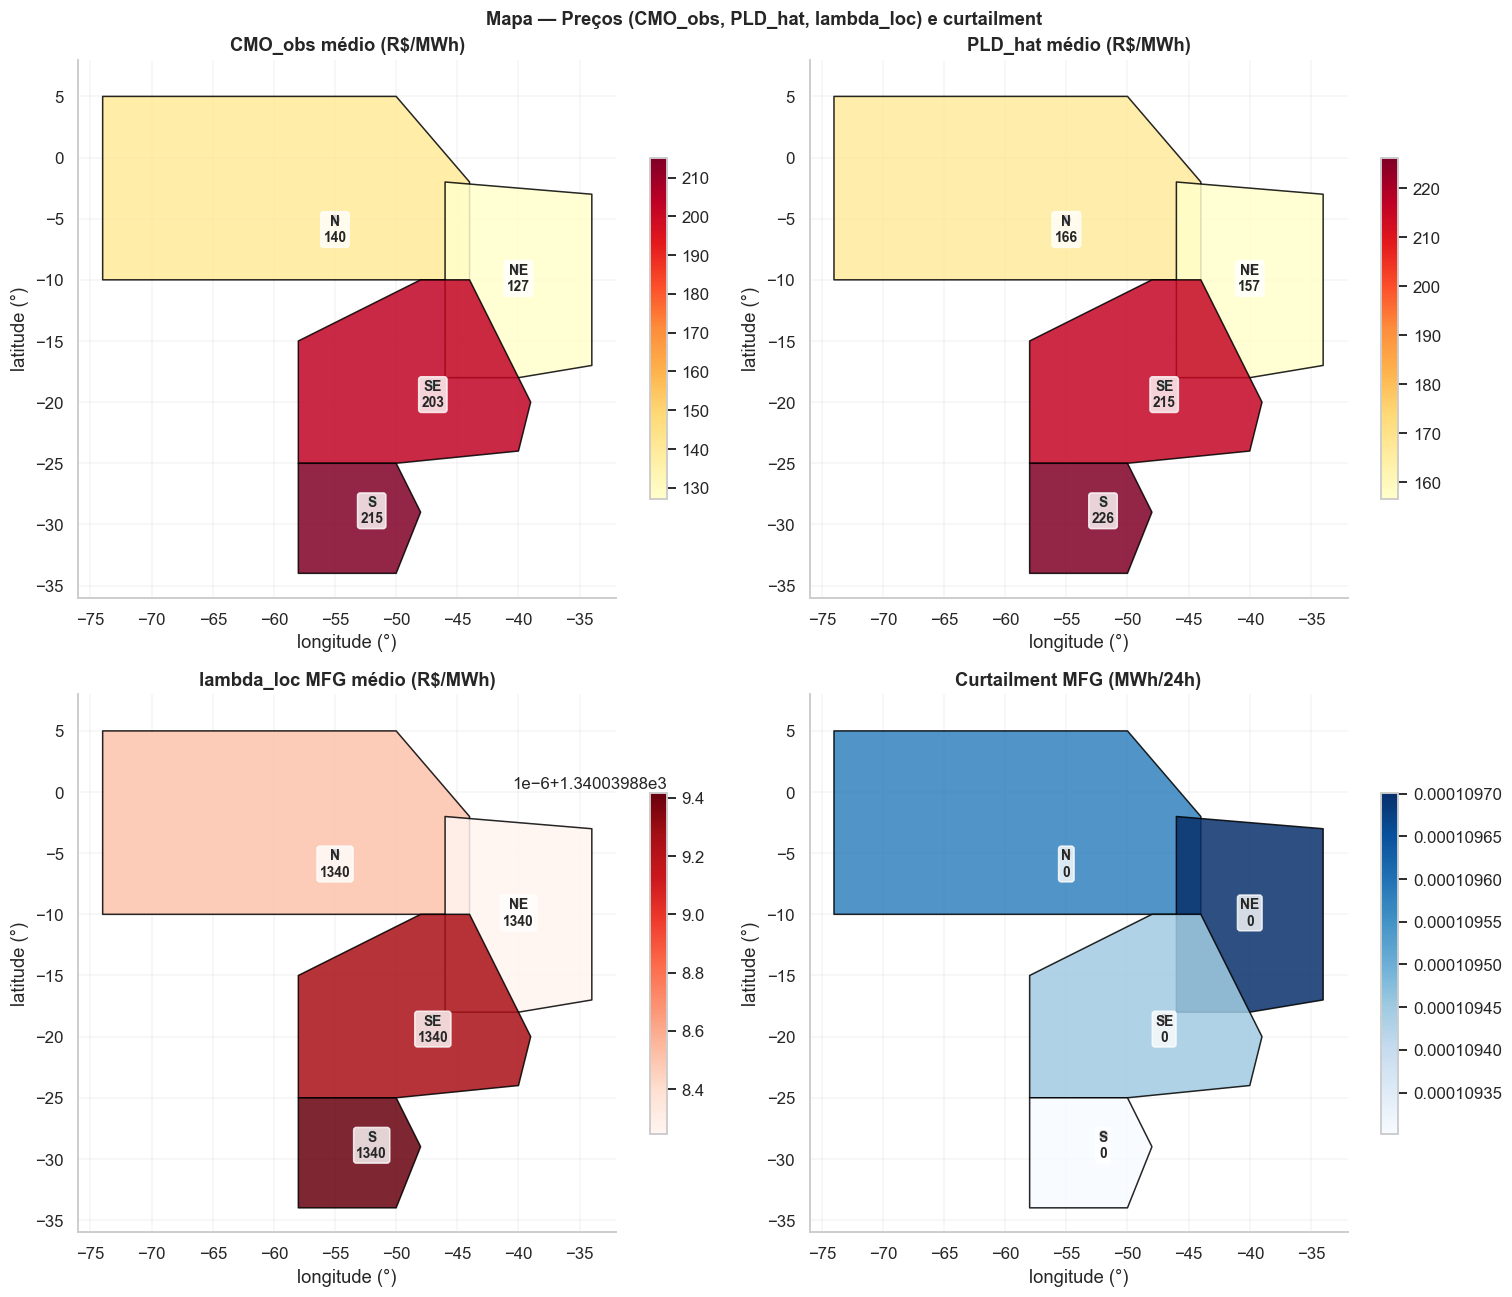

C:\Users\joaof\AppData\Local\Temp\ipykernel_20876\1372290229.py:45: RuntimeWarning: All-NaN slice encountered
  vmin = vmin if vmin is not None else np.nanmin(vals)
C:\Users\joaof\AppData\Local\Temp\ipykernel_20876\1372290229.py:46: RuntimeWarning: All-NaN slice encountered
  vmax = vmax if vmax is not None else np.nanmax(vals)


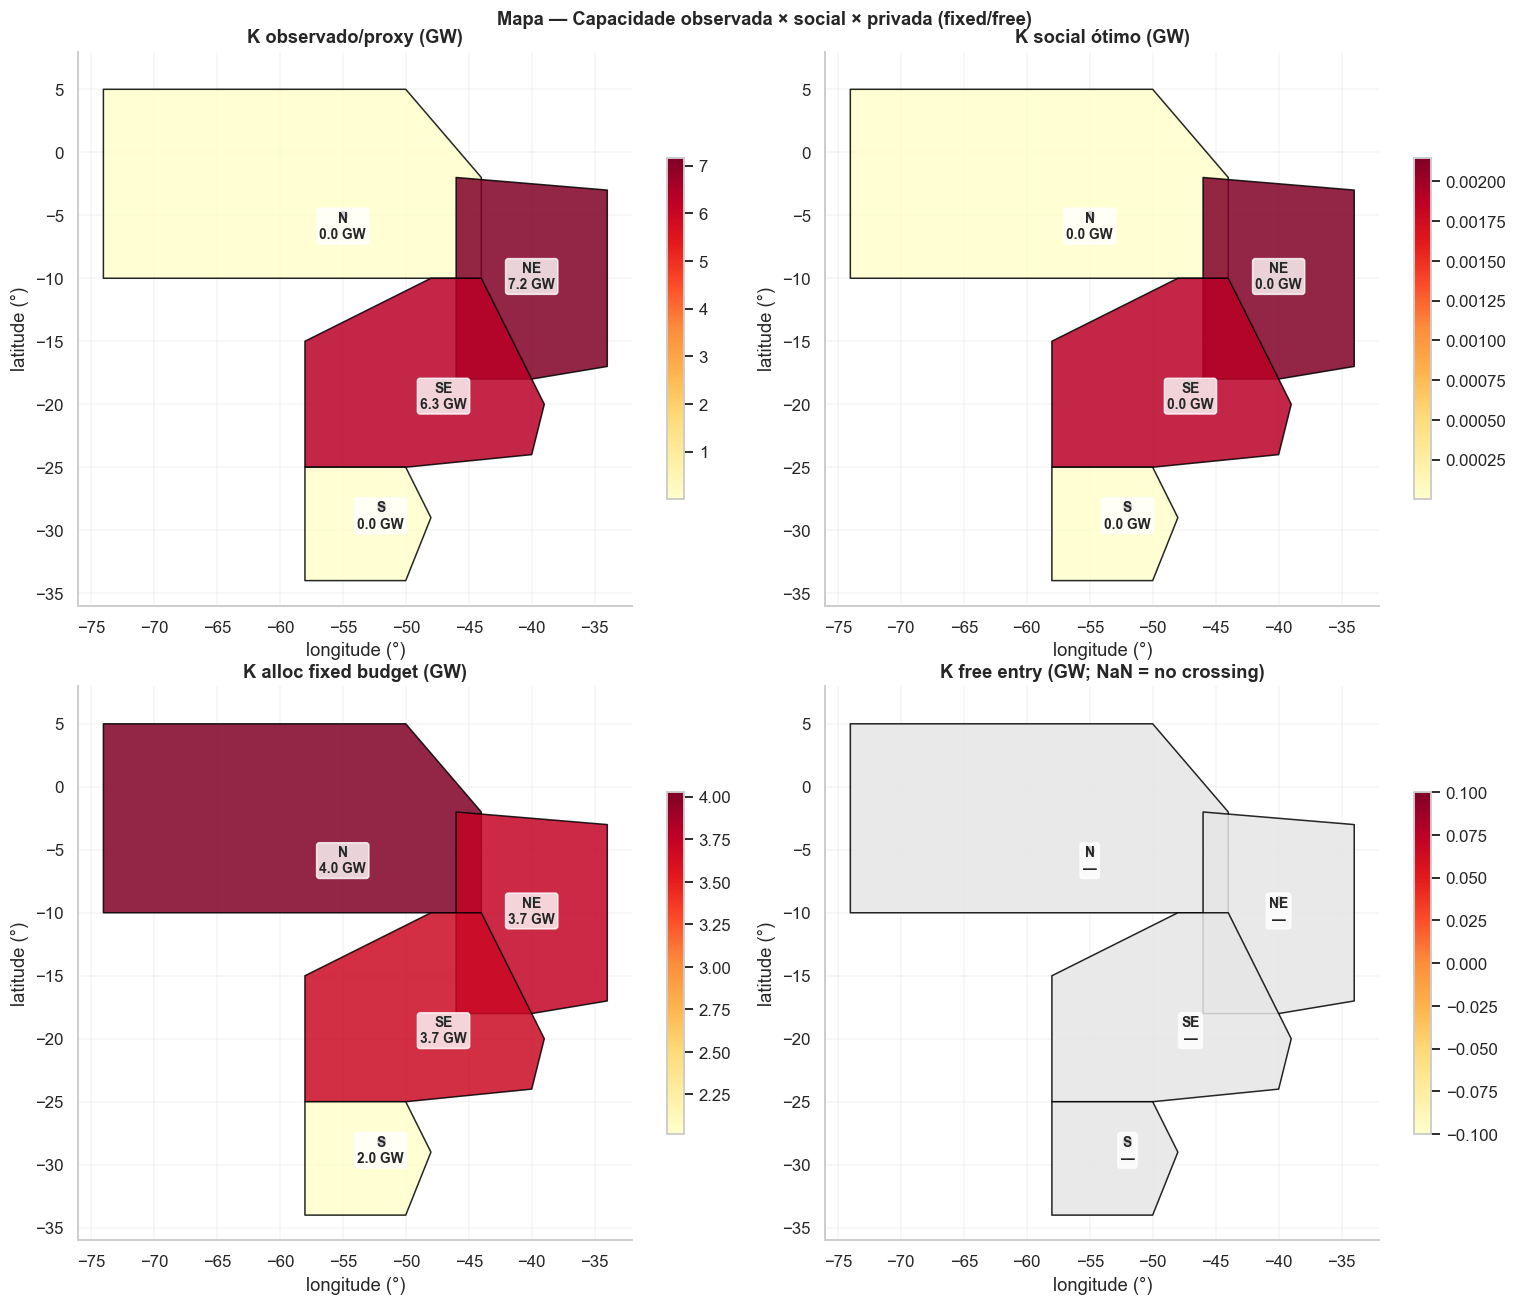

In [30]:
# Mapa 1: solar/wind generation e K_eff_p99 por subsistema
gs_mean = panel.groupby("id_subsistema")["G_s_total"].mean().to_dict()
gw_mean = panel.groupby("id_subsistema")["G_w_total"].mean().to_dict()
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_subsystem_map(axes[0, 0], gs_mean, cmap_name="Oranges",
                   title="Geração solar média (MW)", label_fmt=".0f", label_unit=" MW")
plot_subsystem_map(axes[0, 1], gw_mean, cmap_name="Blues",
                   title="Geração eólica média (MW)", label_fmt=".0f", label_unit=" MW")
plot_subsystem_map(axes[1, 0], {s: K_eff.loc[s, "K_s_eff_p99"]/1000 for s in SUBSYS_ORDER},
                   cmap_name="YlOrRd",
                   title="K_s_eff_p99 (GW, proxy)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[1, 1], {s: K_eff.loc[s, "K_w_eff_p99"]/1000 for s in SUBSYS_ORDER},
                   cmap_name="PuBu",
                   title="K_w_eff_p99 (GW, proxy)", label_fmt=".1f", label_unit=" GW")
fig.suptitle("Mapa — Geração e capacidade renovável (proxy) por subsistema",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "map_solar_wind_by_region.png", bbox_inches="tight")
plt.show()

# Mapa 2: preço médio e curtailment
cmo_mean = panel.groupby("id_subsistema")["CMO_obs"].mean().to_dict()
pld_hat_mean = panel.groupby("id_subsistema")["PLD_hat"].mean().to_dict()
lam_mfg_mean = {ell: float(lam_mfg[ell].mean()) for ell in LOCS}
curt_mfg_by = {ell: float(res_mfg["curt"][ell].sum()) for ell in LOCS}
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_subsystem_map(axes[0, 0], cmo_mean, cmap_name="YlOrRd",
                   title="CMO_obs médio (R$/MWh)", label_fmt=".0f")
plot_subsystem_map(axes[0, 1], pld_hat_mean, cmap_name="YlOrRd",
                   title="PLD_hat médio (R$/MWh)", label_fmt=".0f")
plot_subsystem_map(axes[1, 0], lam_mfg_mean, cmap_name="Reds",
                   title="lambda_loc MFG médio (R$/MWh)", label_fmt=".0f")
plot_subsystem_map(axes[1, 1], curt_mfg_by, cmap_name="Blues",
                   title="Curtailment MFG (MWh/24h)", label_fmt=".0f")
fig.suptitle("Mapa — Preços (CMO_obs, PLD_hat, lambda_loc) e curtailment",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "map_prices_curtailment_by_subsystem.png", bbox_inches="tight")
plt.show()

# Mapa 3: private vs social
K_obs_GW   = {s: K_eff.loc[s, "K_s_eff_p99"]/1000 for s in SUBSYS_ORDER}
K_fixed_GW = {s: K_eq[s]/1000 for s in SUBSYS_ORDER}
K_soc_GW = {s: (K_soc * K_eff.loc[s, "K_s_eff_p99"] / K_TOT)/1000 for s in SUBSYS_ORDER}
if K_priv is not None and K_priv > 0:
    K_priv_GW = {s: (K_priv * 1000 * K_eff.loc[s, "K_s_eff_p99"] / K_TOT)/1000 for s in SUBSYS_ORDER}
else:
    K_priv_GW = {s: np.nan for s in SUBSYS_ORDER}
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_subsystem_map(axes[0, 0], K_obs_GW,   cmap_name="YlOrRd",
                   title="K observado/proxy (GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[0, 1], K_soc_GW,   cmap_name="YlOrRd",
                   title="K social ótimo (GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[1, 0], K_fixed_GW, cmap_name="YlOrRd",
                   title="K alloc fixed budget (GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[1, 1], K_priv_GW,  cmap_name="YlOrRd",
                   title="K free entry (GW; NaN = no crossing)",
                   label_fmt=".1f", label_unit=" GW")
fig.suptitle("Mapa — Capacidade observada × social × privada (fixed/free)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "map_private_vs_social_capacity.png", bbox_inches="tight")
plt.show()


## 21. Apêndice B — métricas consolidadas

In [31]:
metrics = panel.groupby("id_subsistema").agg(
    CMO_obs_avg=("CMO_obs", "mean"),
    CMO_obs_p95=("CMO_obs", lambda x: float(np.nanpercentile(x.dropna(), 95))),
    PLD_hat_avg=("PLD_hat", "mean"),
    L_global_mean=("L_global", "mean"),
    L_global_max=("L_global", "max"),
    L_net_s_mean=("L_net_s", "mean"),
    G_s_total=("G_s_total", "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    Ramp_max_pos=("dL_res", "max"),
    Ramp_max_neg=("dL_res", "min"),
).reindex(SUBSYS_ORDER)

fc_cmo = (fcap.query("tag == 'F_capture_CMO'")
              .pivot_table(index="id_subsistema", columns="fonte", values="F_capture")
              .reindex(SUBSYS_ORDER))
metrics["F_capture_CMO_solar"] = fc_cmo["solar"]
metrics["F_capture_CMO_wind"]  = fc_cmo["wind"]
metrics["K_mfg_solar_MW"] = pd.Series(K_by_subsys_mfg)
metrics["lambda_mfg_mean"] = pd.Series(lam_mfg_mean)
metrics.round(2).to_csv(TABLE_DIR / "tab_apendice_B_metricas.csv")
print(metrics.round(2).to_string())


               CMO_obs_avg  CMO_obs_p95  PLD_hat_avg  L_global_mean  L_global_max  L_net_s_mean    G_s_total    G_w_total     G_h_total  Ramp_max_pos  Ramp_max_neg  F_capture_CMO_solar  F_capture_CMO_wind  K_mfg_solar_MW  lambda_mfg_mean
id_subsistema                                                                                                                                                                                                                                
N                   139.84       340.35       166.19        8788.56      12204.28       8787.33      8742.14   1431912.89  5.930865e+07       1264.89      -1338.20                 0.66                1.36        10597.15          1340.04
NE                  126.96       333.64       156.53       14463.89      20156.18      12532.71  14130877.36  91130920.15  2.351121e+07       5893.64      -5682.43                 0.65                1.22         8151.38          1340.04
SE                  202.75       365.44       21

## 22. Inventário de artefatos

In [32]:
inventory_rows = []

# Mapeamento manual: arquivo -> (tipo, descrição, seção paper, observações)
INVENTORY_META = {
    "tab_coverage_data.csv":                    ("table", "Cobertura temporal dos datasets", "Sec 5", "audit"),
    "tab_capacidades_efetivas_p99.csv":         ("table", "K_*_eff_p99 (proxy de capacidade)", "Sec 5", "proxy"),
    "tab_perfis_horarios_carga.csv":            ("table", "Perfis horários de L_*",            "Sec 5.1", ""),
    "tab_fator_captura.csv":                    ("table", "F_capture agregado",                "Sec 6", "CMO/PLD_hat"),
    "tab_capture_factors_by_season_daytype.csv":("table", "F_capture por estação × tipo_dia",  "Sec 6", "NOVO v3"),
    "tab_params_dispatch.csv":                  ("table", "Parâmetros calibrados do despacho", "Sec 8", ""),
    "tab_despacho_centralizado.csv":            ("table", "Resumo despacho com S_t",           "Sec 8", "reservatório"),
    "tab_situacional_kappa.csv":                ("table", "Sensibilidade situacional (Rev/R_cap)","Sec 9", "v3 corrigido"),
    "tab_feasibility_diagnostics.csv":          ("table", "Diagnóstico de factibilidade",      "Sec 9", "NOVO v3"),
    "tab_valor_agua_cenarios.csv":              ("table", "Sensibilidade hidrológica",         "Sec 8", ""),
    "tab_mfg_history.csv":                      ("table", "Histórico iterações MFG",           "Sec 10–12", "NOVO v3"),
    "tab_mfg_equilibrium_summary.csv":          ("table", "Equilíbrio MFG por subsistema",     "Sec 10–12", "NOVO v3"),
    "tab_mfg_distribution_by_location.csv":     ("table", "Distribuição m no equilíbrio",      "Sec 10–12", "NOVO v3"),
    "tab_investimento_K_grid.csv":              ("table", "Varredura free-entry",              "Sec 13", ""),
    "tab_private_vs_social_capacity.csv":       ("table", "Privado × social",                  "Sec 13", "NOVO v3"),
    "tab_apendice_B_metricas.csv":              ("table", "Métricas consolidadas",             "Apêndice B", ""),

    "fig01_carga_global_rb_res.png":            ("figure", "Perfis L_global/L_RB/L_res",       "Sec 5.1", ""),
    "fig02_diagnostico_operacional.png":        ("figure", "Heatmaps operacionais",            "Sec 5.2", ""),
    "fig04_curva_pato_contrafactual.png":       ("figure", "Curva do pato contrafactual",      "Sec 5.3", ""),
    "fig06_hidrologia_proxy.png":               ("figure", "Séries hidrológicas (PROXY)",      "Sec 7", "PROXY"),
    "fig07_despacho_dia_tipico_SE.png":         ("figure", "Despacho com reservatório (SE)",   "Sec 8", ""),
    "fig09_situacional_sensibilidade.png":      ("figure", "Sensibilidade situacional",        "Sec 9", "Rev/R_cap"),
    "fig13_fator_captura.png":                  ("figure", "F_capture agregado",               "Sec 6", ""),
    "fig_capture_factors_by_season_daytype.png":("figure", "F_capture estação × tipo_dia",     "Sec 6", "NOVO v3"),
    "fig18_valor_agua.png":                     ("figure", "Sensibilidade hidrológica",        "Sec 8", ""),
    "fig_mfg_convergence.png":                  ("figure", "Convergência MFG",                 "Sec 10–12", ""),
    "fig_mfg_distribution_by_location.png":     ("figure", "Distribuição m por subsistema",    "Sec 10–12", ""),
    "fig_mfg_prices_by_location.png":           ("figure", "lambda_loc no equilíbrio",         "Sec 10–12", ""),
    "map_mfg_capacity_by_subsystem.png":        ("figure", "Mapa: K_mfg por subsistema",       "Sec 10–12", ""),
    "map_solar_wind_by_region.png":             ("figure", "Mapa: geração renovável",          "Sec 5", ""),
    "map_prices_curtailment_by_subsystem.png":  ("figure", "Mapa: preços e curtailment",       "Sec 6/8", ""),
    "map_private_vs_social_capacity.png":       ("figure", "Mapa: privado × social",           "Sec 13", ""),
    "fig_private_vs_social_capacity.png":       ("figure", "Curvas Q, I, margem",              "Sec 13", ""),
}

# Verifica o que realmente foi gerado
for d in (FIG_DIR, TABLE_DIR):
    for p in sorted(d.glob("*")):
        if p.suffix not in (".png", ".csv"):
            continue
        meta = INVENTORY_META.get(p.name, ("", "", "", "não catalogado"))
        inventory_rows.append({
            "arquivo": str(p.relative_to(ROOT)),
            "tipo": meta[0],
            "descricao": meta[1],
            "secao_paper": meta[2],
            "observacoes": meta[3],
        })

inv_df = pd.DataFrame(inventory_rows)
inv_df.to_csv(OUT / "artifact_inventory.csv", index=False)
print(f"Inventário ({len(inv_df)} artefatos) -> outputs/artifact_inventory.csv")
print(inv_df.head(10).to_string(index=False))


Inventário (40 artefatos) -> outputs/artifact_inventory.csv
                                            arquivo   tipo                      descricao secao_paper    observacoes
      outputs\figures\fig01_carga_global_rb_res.png figure     Perfis L_global/L_RB/L_res     Sec 5.1               
  outputs\figures\fig02_diagnostico_operacional.png figure          Heatmaps operacionais     Sec 5.2               
 outputs\figures\fig04_curva_pato_contrafactual.png figure    Curva do pato contrafactual     Sec 5.3               
              outputs\figures\fig05_cmo_vs_Lnet.png                                                   não catalogado
         outputs\figures\fig06_hidrologia_proxy.png figure    Séries hidrológicas (PROXY)       Sec 7          PROXY
   outputs\figures\fig07_despacho_dia_tipico_SE.png figure Despacho com reservatório (SE)       Sec 8               
outputs\figures\fig09_situacional_sensibilidade.png figure      Sensibilidade situacional       Sec 9      Rev/R_cap
    

## 23. Validação final (asserts)

In [33]:
assert not panel.empty, "Painel vazio"
assert "L_global" in panel.columns, "L_global ausente"
assert "L_RB" in panel.columns, "L_RB ausente"
assert "L_net_s" in panel.columns, "L_net_s ausente"
assert "L_res" in panel.columns, "L_res ausente"
assert "CMO_obs" in panel.columns, "CMO_obs ausente"
assert "PLD_hat" in panel.columns, "PLD_hat ausente"
assert "G_th_total" in panel.columns and "G_nuc_inflex" in panel.columns, \
    "G_th_total / G_nuc_inflex ausentes"
# lambda_model NUNCA é coluna do painel — vive apenas em resultados de modelos
assert "lambda_model" not in panel.columns, "lambda_model não deve ser coluna do painel"

assert FIG_DIR.exists(), "FIG_DIR ausente"
assert TABLE_DIR.exists(), "TABLE_DIR ausente"
assert (OUT / "artifact_inventory.csv").exists(), "inventário ausente"

# Tabelas essenciais
for fn in ["tab_coverage_data.csv",
           "tab_capture_factors_by_season_daytype.csv",
           "tab_feasibility_diagnostics.csv",
           "tab_mfg_equilibrium_summary.csv",
           "tab_mfg_distribution_by_location.csv",
           "tab_private_vs_social_capacity.csv"]:
    assert (TABLE_DIR / fn).exists(), f"tabela ausente: {fn}"

# Figuras essenciais
for fn in ["fig_capture_factors_by_season_daytype.png",
           "fig_mfg_convergence.png",
           "fig_mfg_distribution_by_location.png",
           "fig_mfg_prices_by_location.png",
           "map_mfg_capacity_by_subsystem.png",
           "map_solar_wind_by_region.png",
           "map_prices_curtailment_by_subsystem.png",
           "map_private_vs_social_capacity.png",
           "fig_private_vs_social_capacity.png"]:
    assert (FIG_DIR / fn).exists(), f"figura ausente: {fn}"

# MFG: distribuição soma 1
assert abs(m_mfg.sum() - 1.0) < 1e-6, f"m_mfg.sum() = {m_mfg.sum()}"

# Receita total != receita capturada (corrige bug do v2)
for k, r in results_sit.items():
    assert "Rev_1_model" in r and "R_cap_1_model" in r, \
        "Rev_*_model e R_cap_*_model devem coexistir"

print("== Validação OK ==")
print(f"Artefatos gerados em {OUT}")


== Validação OK ==
Artefatos gerados em C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy\outputs


## Critério final — checklist v3

| Critério | Status |
| --- | --- |
| `Rev_i_model` (total, R$) × `R_cap_i_model` (R$/MWh) separados | ✅ |
| Curtailment solar explícito por agente: `g_i + curt_i = K_i · a_s,t` | ✅ |
| Diagnóstico de factibilidade `tab_feasibility_diagnostics.csv` | ✅ |
| Nuclear `G_nuc_inflex` separada de térmica `G_th_total` | ✅ |
| Reservatório `S_t` no despacho; `water_opportunity_cost`/`shadow_water_value_proxy` | ✅ |
| `tab_capture_factors_by_season_daytype.csv` + figura | ✅ |
| Mapas: solar/wind, preços/curtailment, privado×social | ✅ |
| MFG locacional **discreto formal** (estado, ação, m, política, forward, clearing, fixed point) | ✅ |
| Livre entrada vs orçamento fixo com interpretação correta | ✅ |
| `outputs/artifact_inventory.csv` + célula de validação | ✅ |
| Sem caminhos absolutos (`Path.cwd()` + auto-detect) | ✅ |
